In [1]:
from IPython.core.interactiveshell import InteractiveShell as IS
IS.ast_node_interactivity = "all"
import pandas as pd
import numpy as np
import statsmodels.api as sm
import pickle
from sklearn.linear_model import ElasticNet, Lasso, Ridge, lasso_path, enet_path
from config import *
import os
import scienceplots
import seaborn as sns
import datetime
import quantstats as qs
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi': 200,
    # 统一字体：SimHei支持中文，Times兼容英文负号（无冲突）
    'font.family': ['SimHei', 'Times New Roman'],
    'font.size': 20,
    'legend.fontsize': 18,
    'lines.linewidth': 5,
    'savefig.bbox': 'tight',
    # 核心：关闭Unicode负号，用ASCII减号（解决负号显示）
    'axes.unicode_minus': False
})

In [2]:
df = pd.read_csv(f"./{prefix}monthly_data.csv", parse_dates=["datetime"])
df.head()

,datetime,instrument,换手率相对波动率,市净率,市现率,市盈率,市销率,涨跌幅,净利润增速,净资产收益率,...,交易量波动率,成交量,振幅,换手率,市值,行业,1M,3M,5M,10M
0,2011-01-31,000001.SZ,0.456526,1.659885,1.239926,8.707913,3.109276,-3.039899,555.6995,19.0618,...,0.622240,4.903733e+08,12.159595,18.978121,4.754304e+10,银行,0.009416,0.108600,0.088512,-0.021343
1,2011-01-31,000002.SZ,0.426794,2.239727,-28.217362,15.974192,2.161215,-0.243309,16.0362,14.0209,...,0.697961,2.091898e+09,16.909976,26.012829,7.921930e+10,房地产,0.064951,-0.039216,-0.001225,-0.084559
2,2011-01-31,000004.SZ,0.576802,14.444693,71.955600,72.597763,8.071581,0.913621,327.5942,19.8969,...,1.094373,1.354612e+07,11.046512,23.455527,1.019108e+09,计算机,-0.041455,-0.106909,-0.020364,-0.411636
3,2011-01-31,000005.SZ,0.279459,4.739232,154.554066,-50.220314,74.173674,-4.632153,-452.9488,-9.4369,...,0.614576,1.159859e+08,13.896458,12.693488,3.198101e+09,公用事业,-0.047059,-0.091765,-0.091765,-0.091765
4,2011-01-31,000006.SZ,2.012407,2.200881,67.034698,11.258796,2.322735,2.008608,227.3132,13.5824,...,0.567617,3.941016e+08,18.938307,88.805896,5.267731e+09,房地产,0.085873,-0.023546,-0.199446,-0.432133


# 数据预处理

In [3]:
def CsProcessFactors(datas):
    '''截面执行预处理'''
    fnormall = []
    dates = datas[date_col].unique()
    for dateuse in tqdm(dates):
        datause = datas.loc[datas[date_col] == dateuse]
        stockname = datause[date_stock_lst + industry_lst]
        # 未来收益数据
        targetdf = datause[target_lst]
        # 因子数据
        factors_data = datause.drop(date_stock_lst + target_lst + industry_lst, axis=1)
        
        # 去极值
        # targetdf = targetdf.apply(lambda x:winsor(x),axis = 0)
        # factors_data = factors_data.apply(lambda x:winsor(x),axis = 0)
        factors_data = filter_extreme(factors_data, type="Percentile", _min=0.05, _max=0.95)
        # targetdf = filter_extreme(targetdf, type="Percentile", _min=0.01, _max=0.99)
        factors_data[market_value_lst] = np.log(factors_data[market_value_lst]).replace(float('-inf'),0)
        
        # zscore
        factors_data = standardize_z(factors_data)
        
        fnormall.append(pd.concat([stockname, targetdf, factors_data], axis=1))
        print('{}预处理完成！'.format(dateuse))
    fnormall = pd.concat(fnormall, axis=0)
    fnormall = fnormall.sort_values(by=date_stock_lst)
    return fnormall.reset_index(drop = True)

def standardize_z(dt):
    '''Z值标准化'''
    mean = dt.mean()     #  截面数据均值
    std = dt.std()       #  截面数据标准差
    return (dt - mean)/std

def winsor(x, _min=5, _max=95):
    if x.dropna().shape[0] != 0:
        x.loc[x < np.percentile(x.dropna(), _min)] = np.percentile(x.dropna(), _min)
        x.loc[x > np.percentile(x.dropna(), _max)] = np.percentile(x.dropna(), _max)
    else:
        x = x.fillna(0)
    return x

In [4]:
data = CsProcessFactors(df)

  0%|          | 0/124 [00:00<?, ?it/s]

2011-01-31T00:00:00.000000000预处理完成！
2011-02-28T00:00:00.000000000预处理完成！
2011-03-31T00:00:00.000000000预处理完成！
2011-04-29T00:00:00.000000000预处理完成！
2011-05-31T00:00:00.000000000预处理完成！
2011-06-30T00:00:00.000000000预处理完成！
2011-07-29T00:00:00.000000000预处理完成！
2011-08-31T00:00:00.000000000预处理完成！
2011-09-30T00:00:00.000000000预处理完成！
2011-10-31T00:00:00.000000000预处理完成！
2011-11-30T00:00:00.000000000预处理完成！
2011-12-30T00:00:00.000000000预处理完成！
2012-01-31T00:00:00.000000000预处理完成！
2012-02-29T00:00:00.000000000预处理完成！
2012-03-30T00:00:00.000000000预处理完成！
2012-04-27T00:00:00.000000000预处理完成！
2012-05-31T00:00:00.000000000预处理完成！
2012-06-29T00:00:00.000000000预处理完成！
2012-07-31T00:00:00.000000000预处理完成！
2012-08-31T00:00:00.000000000预处理完成！
2012-09-28T00:00:00.000000000预处理完成！
2012-10-31T00:00:00.000000000预处理完成！
2012-11-30T00:00:00.000000000预处理完成！
2012-12-31T00:00:00.000000000预处理完成！
2013-01-31T00:00:00.000000000预处理完成！
2013-02-28T00:00:00.000000000预处理完成！
2013-03-29T00:00:00.000000000预处理完成！
2013-04-26T00:00:00.00000000

In [5]:
data.head()
data.shape
data.columns

,datetime,instrument,行业,1M,3M,5M,10M,换手率相对波动率,市净率,市现率,...,营业利润增速,营业收入增速,累计振动升降指标技术,股东权益比率,资金现金回收率,交易量波动率,成交量,振幅,换手率,市值
0,2011-01-31,000001.SZ,银行,0.009416,0.108600,0.088512,-0.021343,-0.584515,-1.150260,-0.226998,...,3.158336,-0.507100,-2.972825,-1.645895,0.283258,-0.010465,3.012026,-1.283349,-0.876369,2.120147
1,2011-01-31,000002.SZ,房地产,0.064951,-0.039216,-0.001225,-0.084559,-0.621015,-0.951068,-0.511976,...,-0.499833,-1.341502,-2.972825,-1.305793,-0.775457,0.414102,3.012026,-0.484444,-0.632041,2.120147
2,2011-01-31,000004.SZ,计算机,-0.041455,-0.106909,-0.020364,-0.411636,-0.436859,2.680992,0.457127,...,2.474313,2.537240,-0.277429,0.590042,0.446986,2.636784,-0.769777,-1.470545,-0.720860,-1.142613
3,2011-01-31,000005.SZ,公用事业,-0.047059,-0.091765,-0.091765,-0.091765,-0.801889,-0.042845,1.256209,...,-0.929440,-1.522111,-0.217577,-0.136835,-0.343615,-0.053438,0.143500,-0.991249,-1.089254,0.012108
4,2011-01-31,000006.SZ,房地产,0.085873,-0.023546,-0.199446,-0.432133,1.325544,-0.965183,0.409521,...,3.158336,2.537240,-2.719129,-1.270994,-0.421182,-0.316737,2.622975,-0.143325,1.548874,0.515990


(363427, 25)

Index(['datetime', 'instrument', '行业', '1M', '3M', '5M', '10M', '换手率相对波动率',
       '市净率', '市现率', '市盈率', '市销率', '涨跌幅', '净利润增速', '净资产收益率', '营业利润增速',
       '营业收入增速', '累计振动升降指标技术', '股东权益比率', '资金现金回收率', '交易量波动率', '成交量', '振幅',
       '换手率', '市值'],
      dtype='object')

In [6]:
# output = open('./process_data.pkl', 'wb')
# pickle.dump([date_stock_lst, target_lst, factors_lst, industry_lst], output)
# output.close()

In [7]:
# data.to_csv(f"{prefix}clean_data.csv", index=False)

In [8]:
data = pd.read_csv(f"./{prefix}clean_data.csv", parse_dates=["datetime"])

# 识别有效因子

In [9]:
target = "1M"
test_factor = "市值"
test_factor_lst = ["市值", "市净率"]
target_lst = ["1M", "3M", "5M", "10M"]
bt_indicators = ["Cumulative Return", "Volatility (ann.)", "Sharpe", "Max Drawdown", "Sortino", "Omega"]
test_target_lst = target_lst
cust_num = 3
cust_num_labeldict = {market_value_col:['Small', 'Medium', 'Big'], "市净率":["Low", "Medium", "High"]}

## 因子收益率t检验

In [10]:
def singlefactor(x, exog, endog, para=True):
    '''
    x: 单因子
    exog：行业和市值
    endog：收益率
    '''
    X = pd.concat([exog, x], axis=1)
    model = sm.OLS(endog=endog, exog=X).fit()
    if para:
        params = model.params
        params.index = exog.columns.tolist() + ['factor']
        return params
    else:
        # params = params[x.name]
        tvalues = model.tvalues
        # tvalues = tvalues[x.name]
        tvalues.index = exog.columns.tolist() + ['factor']
        return tvalues

In [11]:
industry_onehot = pd.get_dummies(data[industry_lst], prefix='industry')
industry_onehot['Intercept'] = 1
# 行业和市值列
exog_cols = industry_onehot.columns.tolist() + market_value_lst
# 新的因子数据
industry_onehot[date_stock_lst] = data[date_stock_lst]
sglfacdata = pd.merge(data, industry_onehot, on=date_stock_lst)

In [12]:
params_lst = []
tvalues_lst = []
# 截面回归
for t in sglfacdata[date_col].unique():
    T_data = sglfacdata[sglfacdata[date_col]==t]
    endog = T_data[target]
    exog = T_data[exog_cols]
    # 因子收益率估计
    tmp_params = T_data[factors_lst].apply(func=singlefactor, args=(exog,endog,True), axis=0).T[['factor']]
    tmp_params.columns = [t]
    params_lst.append(tmp_params)
    # t检验
    tmp_tvalues = T_data[factors_lst].apply(func=singlefactor, args=(exog,endog,False), axis=0).T[['factor']]
    tmp_tvalues.columns = [t]
    tvalues_lst.append(tmp_tvalues)
    
# 因子收益率
gammas = pd.concat(params_lst, axis=1).T
# t值
tvalues = pd.concat(tvalues_lst, axis=1).T

## 计算IC

In [13]:
def OlsResid(y, x):
    # 因子y和行业,市值x的回归残差
    df = pd.concat([y, x], axis=1)
    if df.dropna().shape[0]>0:
        resid = sm.OLS(y, x, missing='drop').fit().resid
        return resid.reindex(df.index)
    else:
        return y
    
def neutral_factor(data):
    """
    中性化
    """    
    industry = data[industry_lst]
    market_value = data[market_value_lst]

    # 删除市值和industry
    data_info = data[industry_lst+market_value_lst+date_stock_lst]
    data = data.drop(columns=industry_lst+market_value_lst+date_stock_lst)

    # 中性化，每个因子对industry和市值做回归，得到残差值
    industry_onehot = pd.get_dummies(industry, prefix='industry', prefix_sep="_", dummy_na=False, drop_first=True)
    industry_onehot[market_value_lst] = market_value
    industry_onehot['Intercept'] = 1
    data = data.apply(func=OlsResid, args=(industry_onehot,), axis=0)
    data1 = pd.concat([data, data_info], axis=1)
    return data1

In [14]:
def getICSeries(factors_data, factors_lst, target):
    '''若干因子和target的相关系数'''
    icall= factors_data[[date_col]+factors_lst+[target]].groupby(date_col).apply(lambda x: x.corr(method='spearman')[target]).reset_index()
    icall = icall.dropna().drop([target], axis=1).set_index(date_col)
    return icall

In [15]:
icdata = neutral_factor(data)

In [16]:
icall = getICSeries(icdata, factors_lst, target)

C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\2774934527.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  icall= factors_data[[date_col]+factors_lst+[target]].groupby(date_col).apply(lambda x: x.corr(method='spearman')[target]).reset_index()


In [17]:
icall

1M,换手率相对波动率,市净率,市现率,市盈率,市销率,涨跌幅,净利润增速,净资产收益率,营业利润增速,营业收入增速,累计振动升降指标技术,股东权益比率,资金现金回收率,交易量波动率,成交量,振幅,换手率,市值
datetime,,,,,,,,,,,,,,,,,,
2011-01-31,-0.137237,-0.042874,-0.117201,-0.106789,-0.169087,0.145202,-0.023242,-0.185842,-0.024846,-0.037245,0.094488,-0.211296,-0.054851,0.071971,0.074750,-0.220689,-0.156939,0.046948
2011-02-28,-0.109224,-0.014519,-0.057000,-0.067501,-0.090046,-0.053037,-0.038679,-0.145672,-0.055963,-0.087942,0.075267,-0.143583,0.012885,0.066197,0.030032,-0.085698,-0.160117,0.212717
2011-03-31,-0.035860,0.025306,-0.059606,0.035624,-0.055073,-0.002145,-0.060935,-0.038394,-0.060877,-0.090906,0.047635,-0.065517,0.035220,0.075962,-0.000080,-0.024453,-0.051828,0.142915
2011-04-29,0.087755,0.095020,0.004408,0.013206,0.016873,-0.063350,0.057576,0.019433,0.057910,0.071812,0.010201,-0.054108,-0.024228,0.062480,0.007783,0.185309,0.101446,-0.017545
2011-05-31,-0.085975,0.049105,0.041837,0.003218,0.090783,0.009945,0.116627,0.058698,0.114968,0.072077,-0.128860,0.079957,0.083840,-0.016792,-0.100105,-0.060405,-0.106974,-0.170989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-31,-0.174747,-0.202415,-0.139364,-0.140103,-0.177635,-0.215511,-0.084597,-0.086244,-0.086931,-0.120584,-0.102648,-0.087630,-0.041537,0.045858,0.073146,-0.127110,-0.153279,-0.101696
2021-01-29,-0.198287,-0.184581,-0.110114,-0.130390,-0.163500,-0.025928,-0.047170,-0.051013,-0.050312,-0.099399,-0.088152,-0.087325,-0.036146,0.100824,-0.028108,-0.189926,-0.220708,-0.148879
2021-02-26,0.019089,0.045865,0.036155,0.080667,0.093439,-0.075759,-0.053761,-0.059767,-0.050495,-0.022843,0.044425,0.057200,-0.001376,0.050671,-0.021593,0.052039,0.019050,0.115441


## 输出指标

In [18]:
start_date = '2017-01-01'
selected_gammas = gammas[gammas.index>f"{start_date}"]
selected_tvalues = tvalues[tvalues.index>f"{start_date}"]
selected_icall = icall[icall.index>f"{start_date}"]

In [19]:
metrics = pd.DataFrame()
metrics["abs(tvalues) mean"] = np.abs(selected_tvalues).mean()
metrics["abs(tvalues)>2"] = (np.abs(selected_tvalues)>2).mean()
metrics["因子收益率均值"] = selected_gammas.mean()
metrics["因子收益率标准差"] = selected_gammas.std()
metrics["IC mean"] = selected_icall.mean()
metrics["IC std"] = selected_icall.std()
metrics["IR"] = selected_icall.mean()/icall.std()
metrics["abs(IC)>0.03"] = (abs(selected_icall)>0.03).mean(axis=0) # IC系数超过0.03的比例
metrics

,abs(tvalues) mean,abs(tvalues)>2,因子收益率均值,因子收益率标准差,IC mean,IC std,IR,abs(IC)>0.03
换手率相对波动率,4.466834,0.730769,-0.006546,0.009523,-0.055458,0.092483,-0.617858,0.673077
市净率,4.032960,0.673077,-0.001815,0.010044,-0.034459,0.098553,-0.374948,0.750000
市现率,1.360180,0.192308,-0.000074,0.003377,-0.012258,0.054922,-0.241118,0.615385
市盈率,1.983446,0.403846,-0.000397,0.004830,-0.017877,0.061171,-0.308425,0.730769
市销率,3.441855,0.634615,-0.001725,0.008576,-0.022565,0.073785,-0.304988,0.692308
涨跌幅,3.155633,0.557692,-0.001838,0.008702,-0.018940,0.097364,-0.174644,0.788462
净利润增速,2.697616,0.576923,-0.000104,0.006303,-0.001813,0.059282,-0.029598,0.711538
净资产收益率,4.034233,0.730769,-0.001014,0.009386,0.000682,0.088969,0.007605,0.769231
营业利润增速,2.585299,0.538462,0.000303,0.006228,0.002086,0.057887,0.035258,0.653846
营业收入增速,2.793187,0.519231,-0.000320,0.006600,0.004905,0.062657,0.071367,0.692308


In [20]:
metrics.applymap(lambda x:"{:.3f}".format(x)).to_csv("metrics.csv", encoding='utf_8_sig')

In [21]:
select_metrics = metrics[abs(metrics["abs(IC)>0.03"])>0.6]
select_metrics = select_metrics.sort_values(by=["因子收益率均值"])
select_metrics

,abs(tvalues) mean,abs(tvalues)>2,因子收益率均值,因子收益率标准差,IC mean,IC std,IR,abs(IC)>0.03
换手率相对波动率,4.466834,0.730769,-0.006546,0.009523,-0.055458,0.092483,-0.617858,0.673077
换手率,4.874209,0.769231,-0.006420,0.010257,-0.068649,0.102737,-0.635155,0.846154
成交量,3.223360,0.538462,-0.002741,0.009171,-0.056907,0.088431,-0.626190,0.750000
涨跌幅,3.155633,0.557692,-0.001838,0.008702,-0.018940,0.097364,-0.174644,0.788462
市净率,4.032960,0.673077,-0.001815,0.010044,-0.034459,0.098553,-0.374948,0.750000
市销率,3.441855,0.634615,-0.001725,0.008576,-0.022565,0.073785,-0.304988,0.692308
振幅,3.775479,0.692308,-0.001651,0.009664,-0.057162,0.105293,-0.495947,0.846154
净资产收益率,4.034233,0.730769,-0.001014,0.009386,0.000682,0.088969,0.007605,0.769231
市盈率,1.983446,0.403846,-0.000397,0.004830,-0.017877,0.061171,-0.308425,0.730769
营业收入增速,2.793187,0.519231,-0.000320,0.006600,0.004905,0.062657,0.071367,0.692308


<Axes: >

<Axes: >

Text(0.5, 0, '因子')

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 [Text(0, 0, '换手率相对波动率'),
  Text(1, 0, '换手率'),
  Text(2, 0, '成交量'),
  Text(3, 0, '涨跌幅'),
  Text(4, 0, '市净率'),
  Text(5, 0, '市销率'),
  Text(6, 0, '振幅'),
  Text(7, 0, '净资产收益率'),
  Text(8, 0, '市盈率'),
  Text(9, 0, '营业收入增速'),
  Text(10, 0, '净利润增速'),
  Text(11, 0, '市现率'),
  Text(12, 0, '营业利润增速'),
  Text(13, 0, '市值'),
  Text(14, 0, '资金现金回收率')])

Text(0.5, 1.0, 'abs(tvalues) mean')

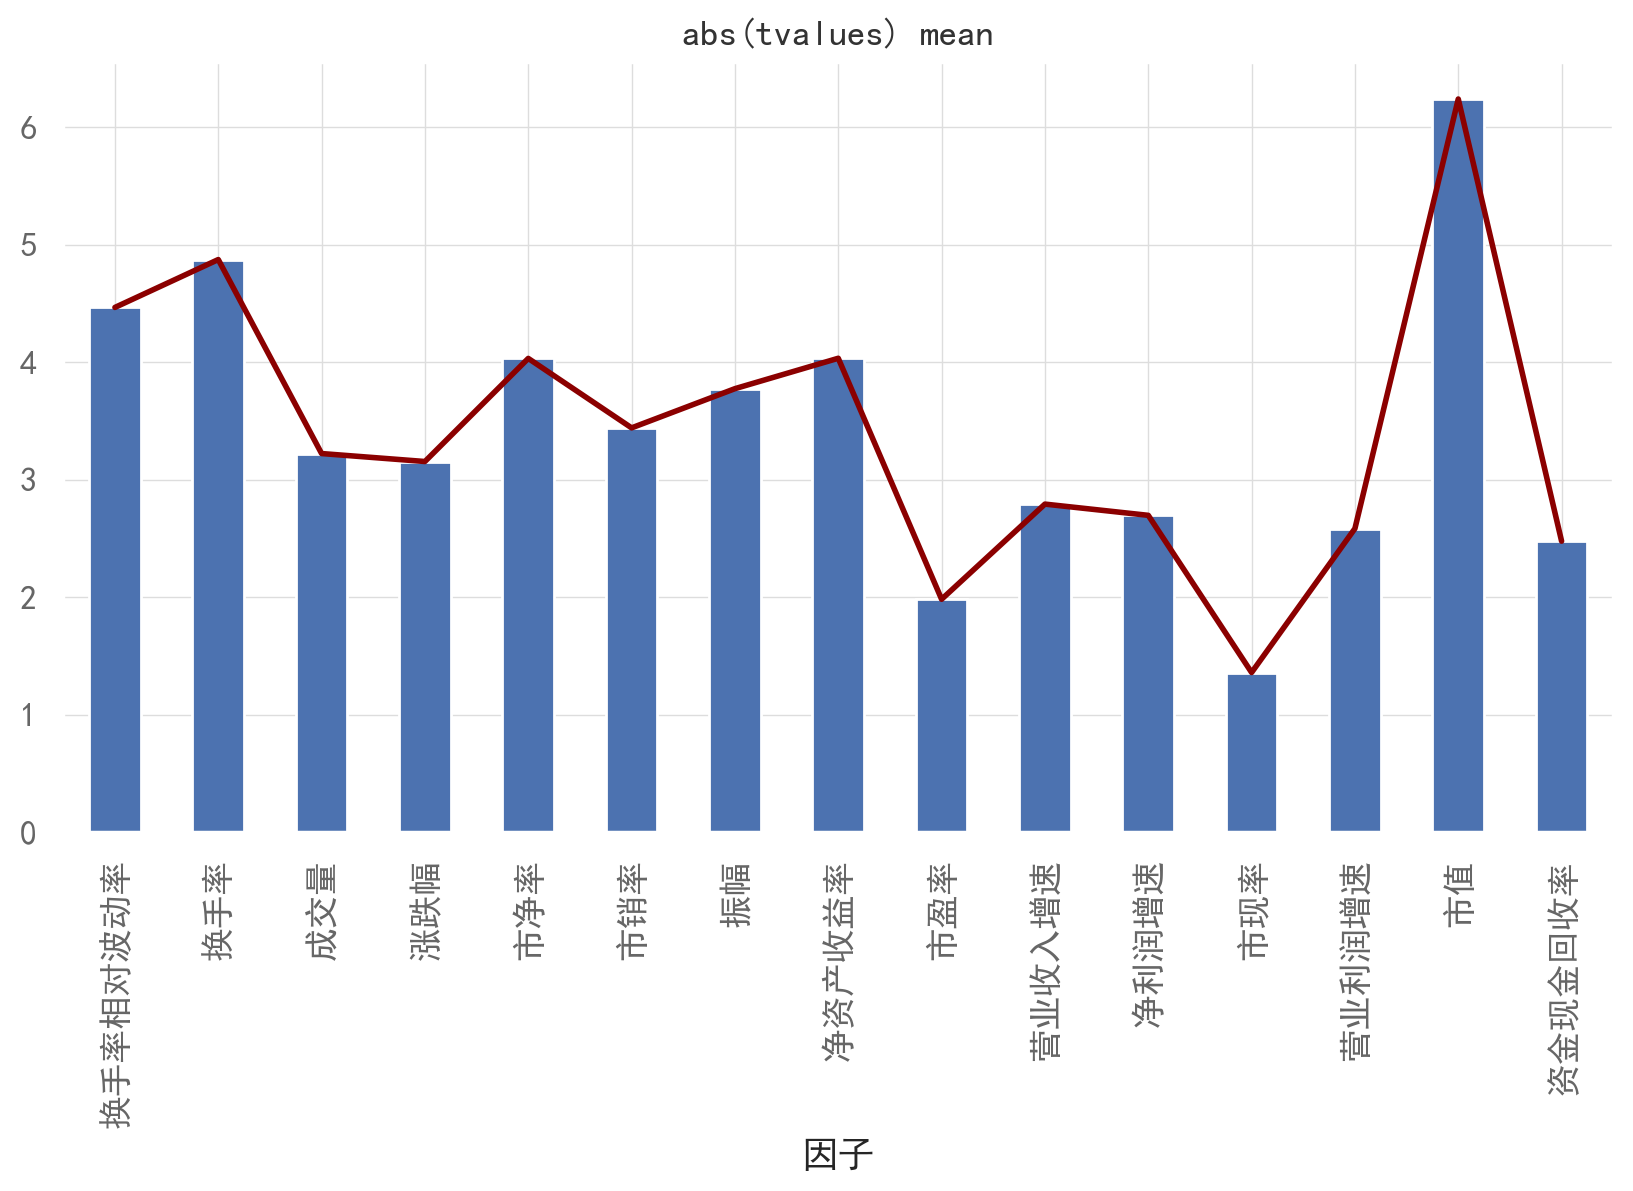

In [22]:
for col in select_metrics.columns:
    fig = plt.figure(figsize = (10,5))
    select_metrics[col].plot(kind='bar')
    select_metrics[col].plot(kind='line', color='darkred', linewidth=2)
    plt.xlabel("因子")
    plt.xticks(rotation=90)
    plt.title(f'{col}')
    if ">" in col:
        col = "IC绝对值"
    break
    # plt.savefig(f"{col}.png", dpi=500, bbox_inches = 'tight')

## 单调性检验

In [23]:
def groupReturn(subdf):
    cut = pd.cut(subdf[test_factor], cust_num, labels=cust_num_lst)
    sub_day_group = subdf.groupby(cut)[target].mean()#.unstack().reset_index(drop=True)
    return sub_day_group

In [24]:
def getPreDate(idx, gap=1):
    idx = pd.to_datetime(idx)
    date = idx.min()
    return _getPreDate(date, gap=1)

def _getPreDate(date, gap=1):
    '''输入日期的前gap月的日期'''
    year = date.year
    month = date.month
    day = date.day
    tmp_month = month - gap
    pre_month = tmp_month+12 if tmp_month <= 0 else tmp_month
    pre_year = year-1 if tmp_month <= 0 else year
    pre_day = '01'
    mindate = datetime.datetime.strptime(f"{pre_year}-{pre_month}-{pre_day}", "%Y-%m-%d")
    return mindate

<Axes: >

Text(0, 0.5, '月均收益')

Text(0.5, 0, '时间')

[Text(0, 0, '2010-12'), Text(60, 0, '2015-12'), Text(120, 0, '2020-12')]

<Axes: >

Text(0, 0.5, '月均收益')

Text(0.5, 0, '时间')

[Text(0, 0, '2010-12'), Text(60, 0, '2015-12'), Text(120, 0, '2020-12')]

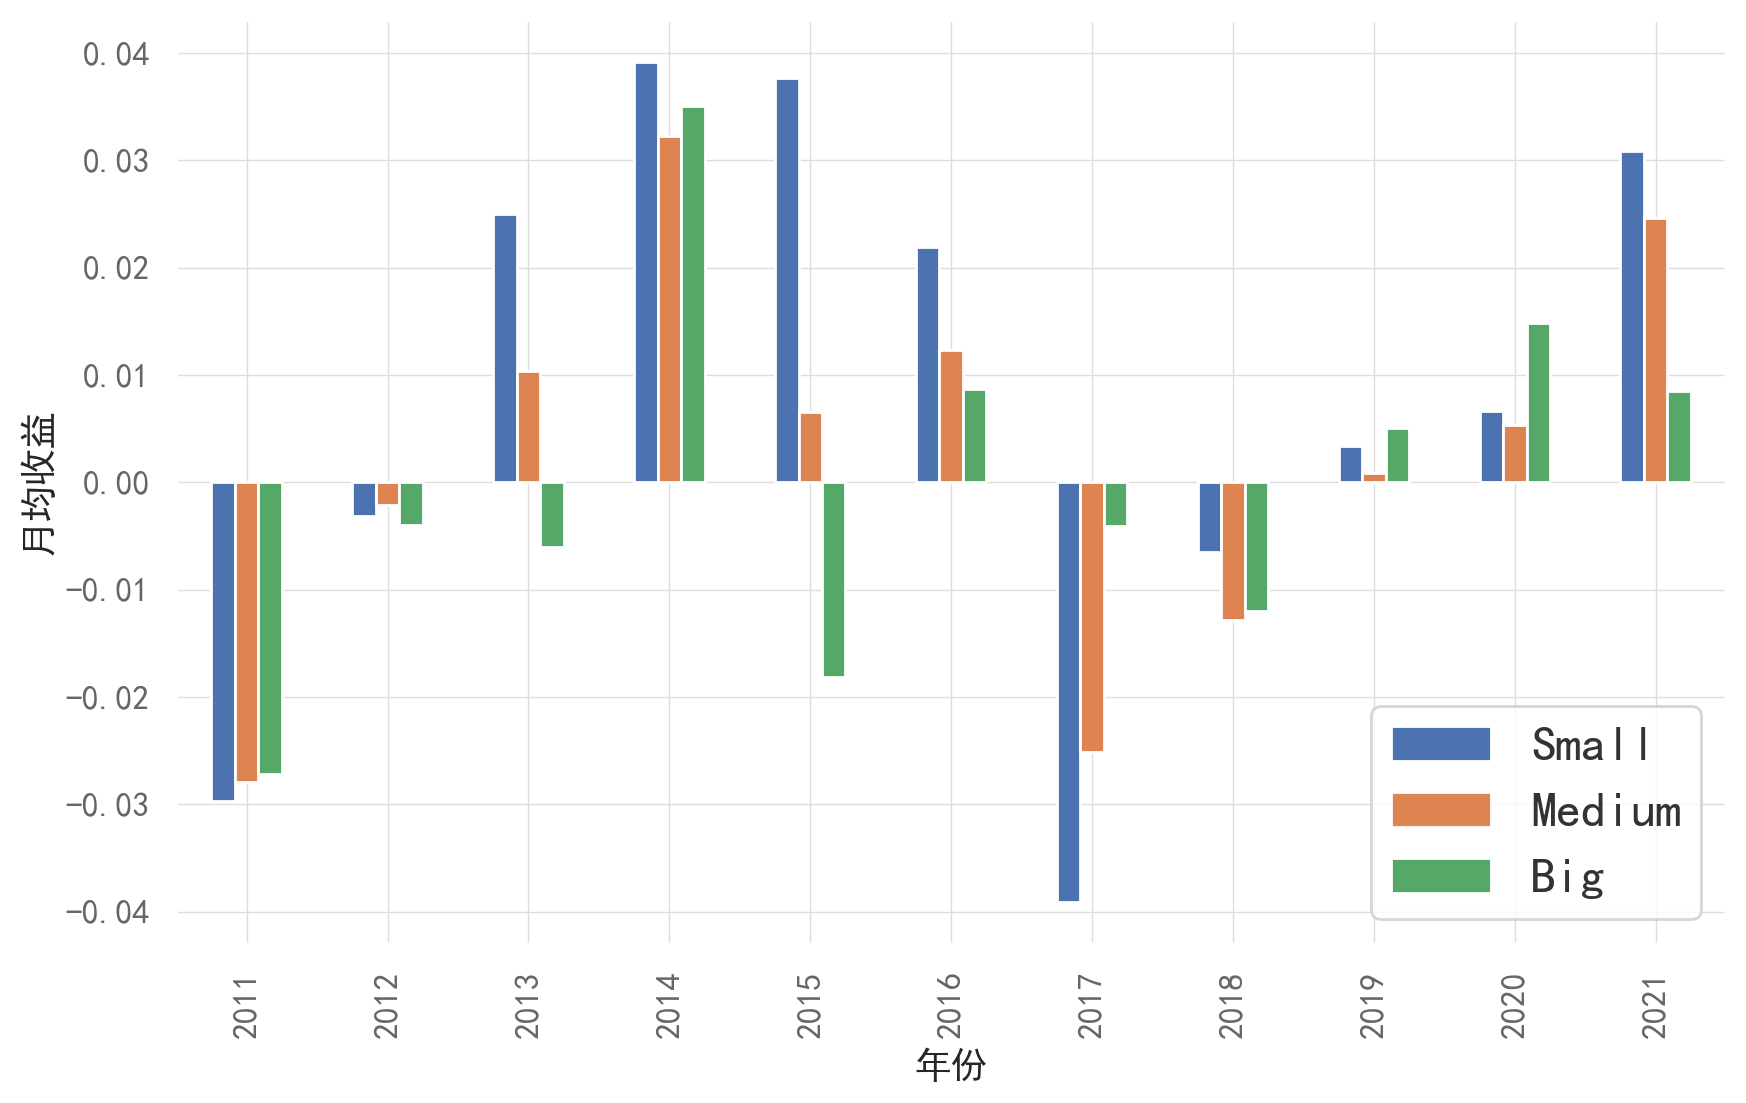

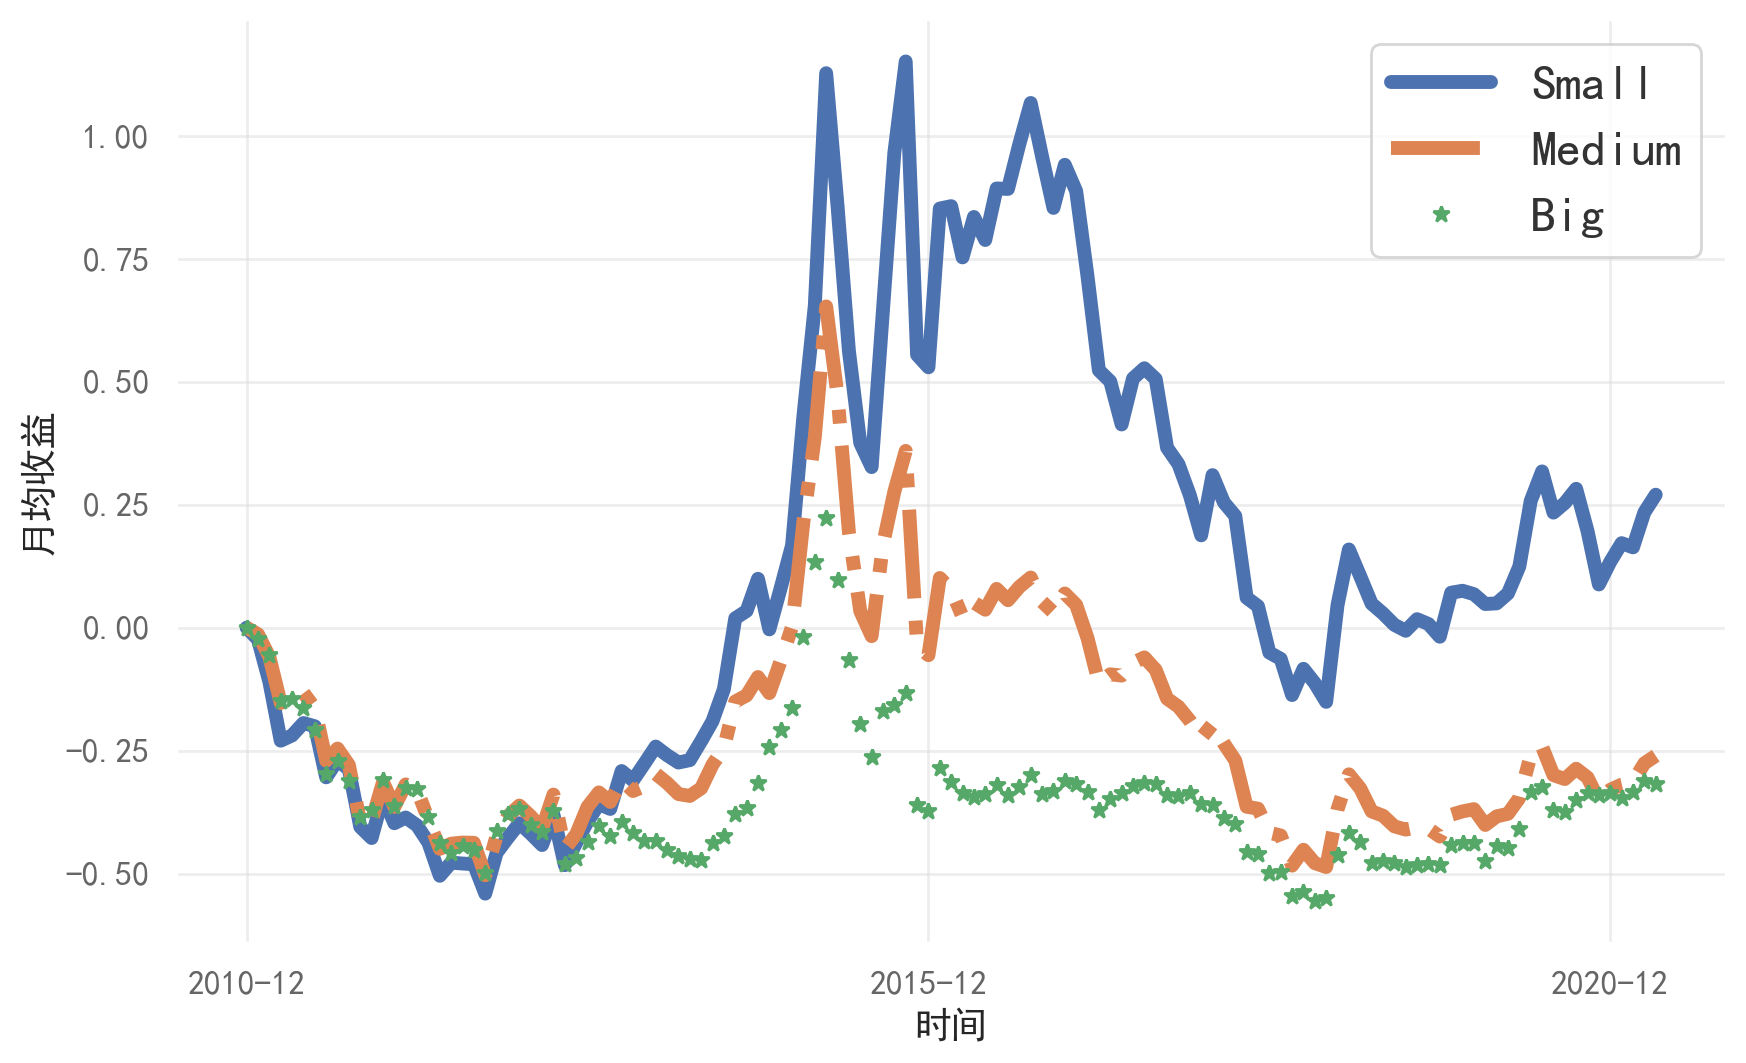

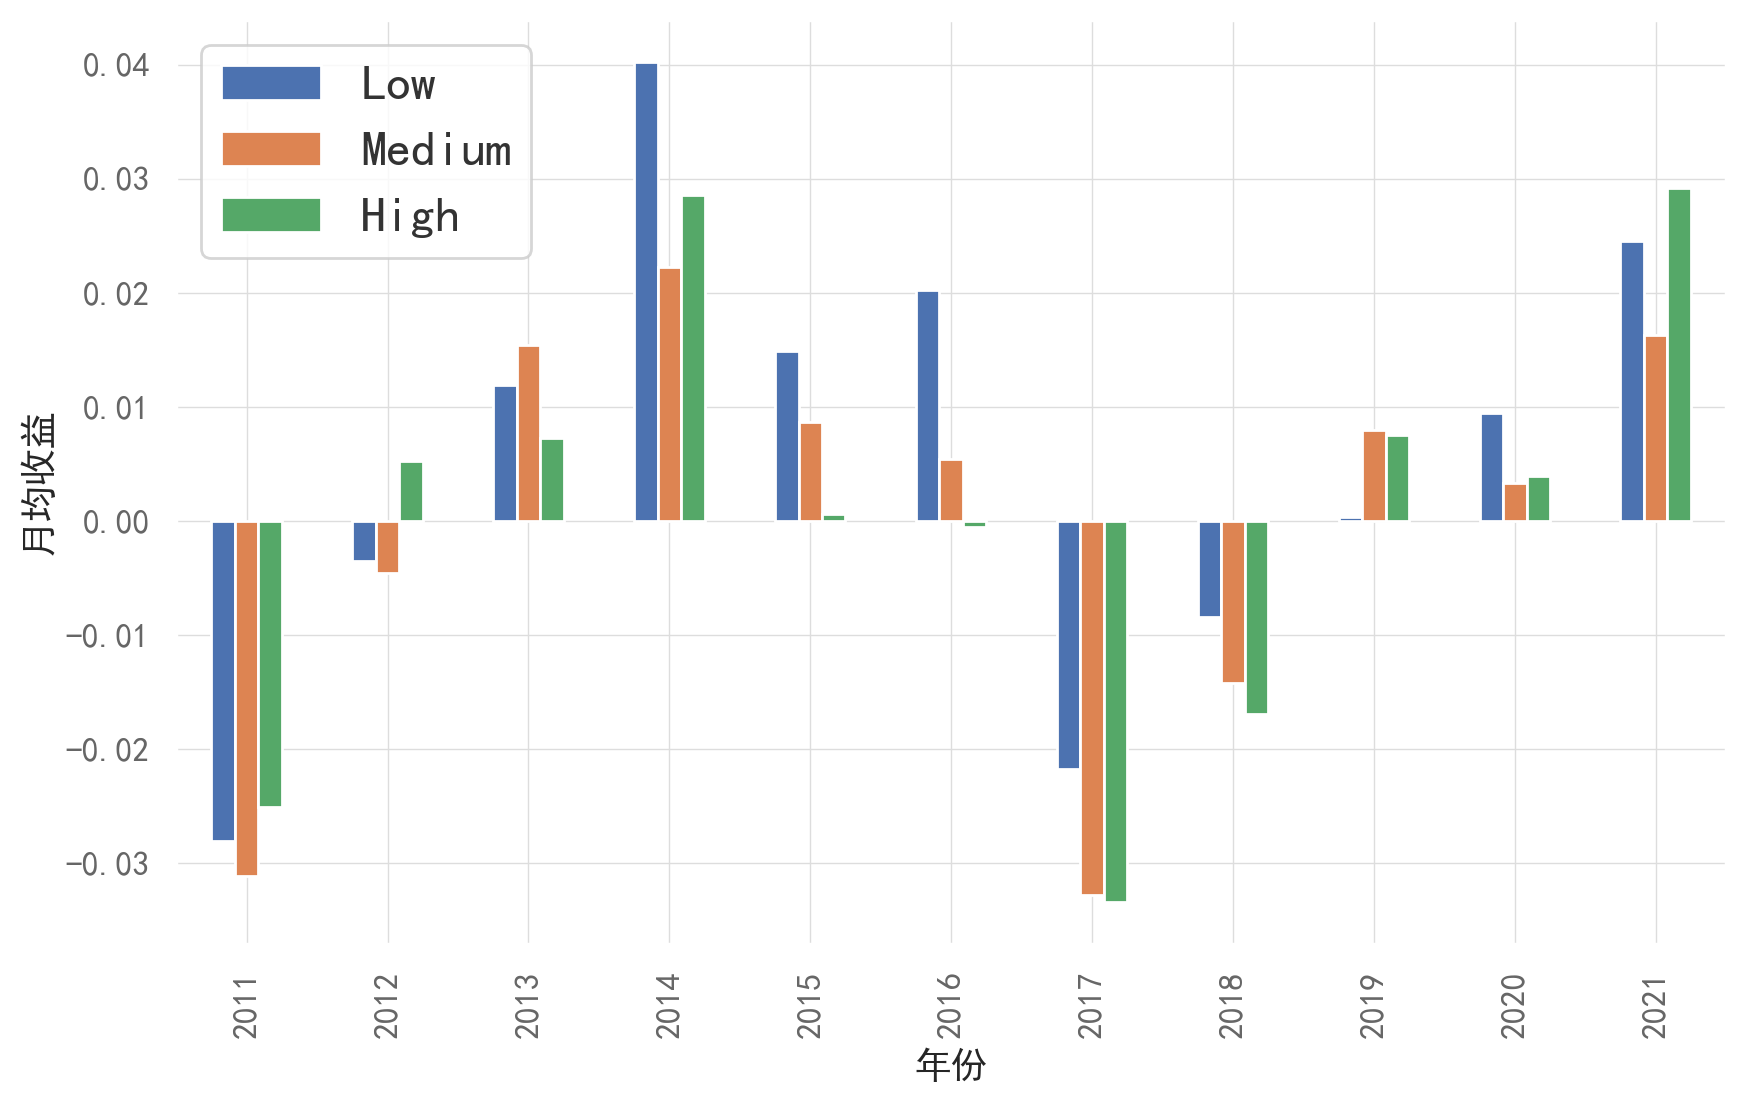

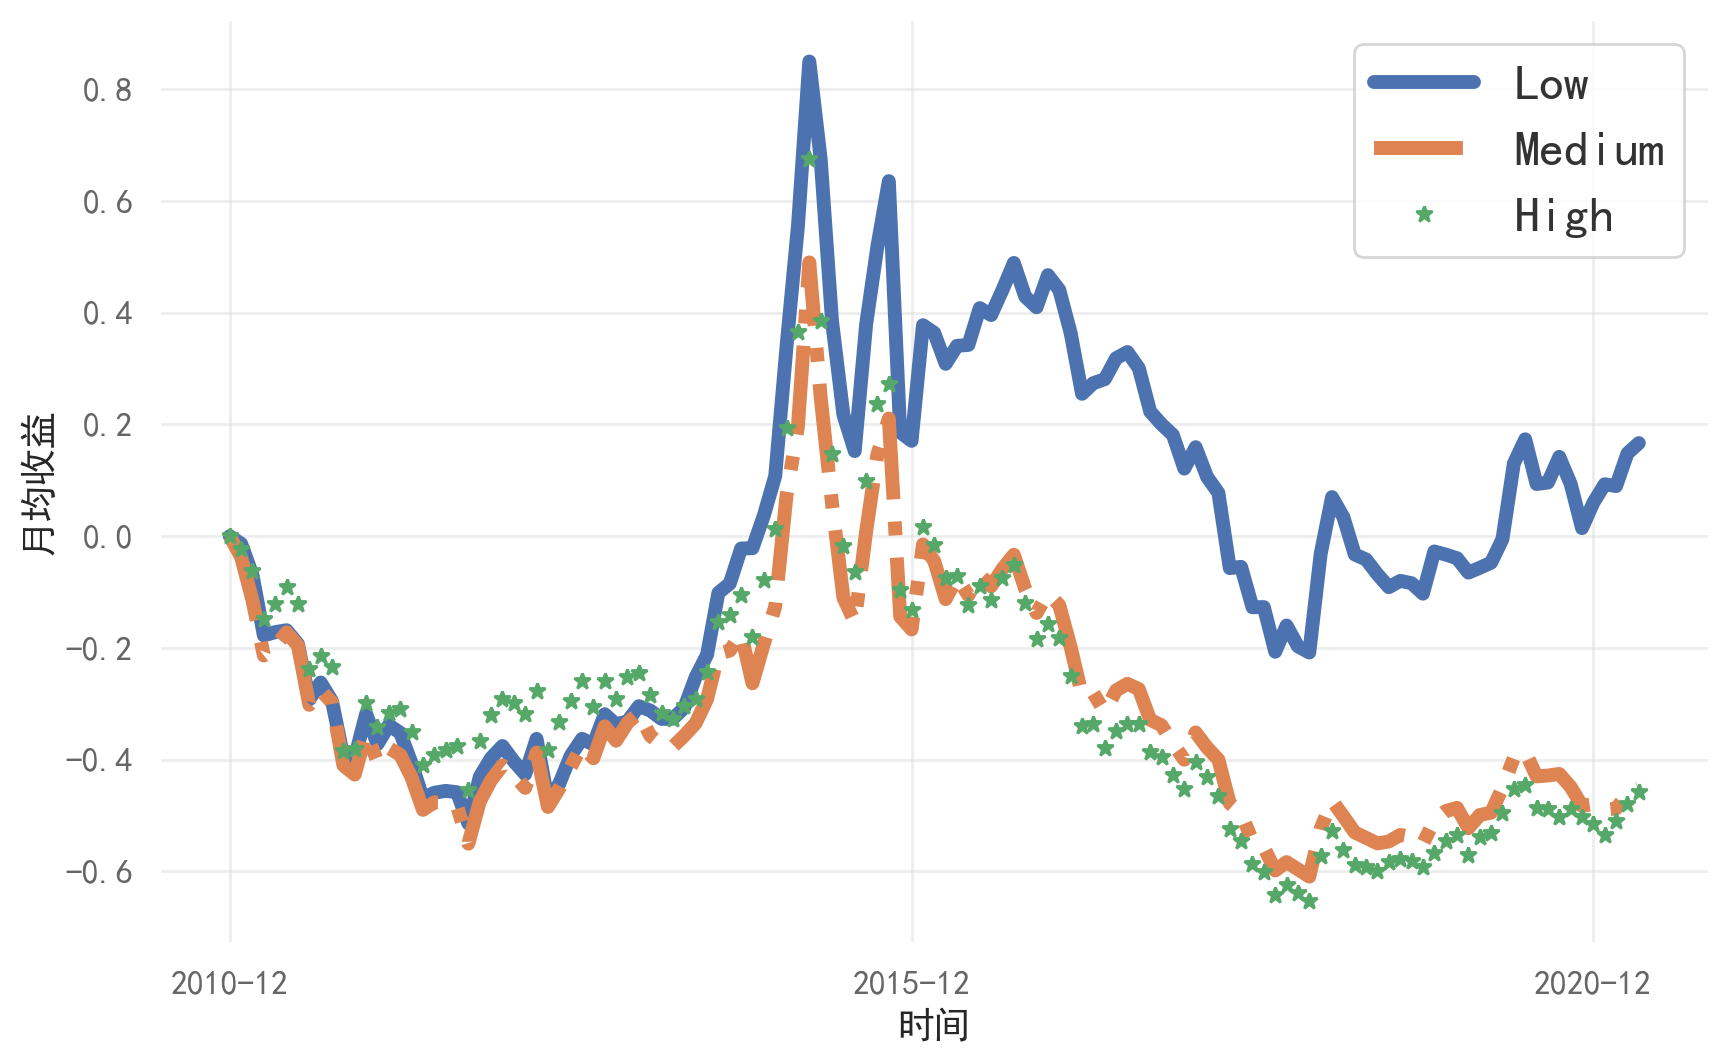

In [25]:
dic = {"市值":"size", "市净率":"mb"}
for test_factor in test_factor_lst:
    cust_num_lst = cust_num_labeldict.get(test_factor, ["1", "2", "3"])
    # 日期，因子，收益率
    tmp_data = data[[date_col, test_factor, target]]
    data_cut = pd.cut(tmp_data[test_factor], cust_num, labels=cust_num_lst)
    tmp_year_group = tmp_data.groupby([tmp_data[date_col].dt.year, data_cut])[target].mean().unstack()
    _ = tmp_year_group.plot.bar(figsize=(10, 6), align='center');
    _ = plt.ylabel('月均收益')
    _ = plt.xlabel('年份')
    _ = plt.legend(loc = "best")
    plt.savefig(generateFilePath(f"{dic.get(test_factor)}bar"), bbox_inches='tight', dpi=200)
    
    # 收益率明细
    tmp_day_group = tmp_data.groupby(tmp_data[date_col]).apply(groupReturn)
    mindate = getPreDate(tmp_day_group.index)
    tmp_day_group.loc[f"{mindate}", :] = 0
    tmp_day_group = tmp_day_group.sort_index()
    
    # xticks
    skip = 60
    idx = pd.to_datetime(tmp_day_group.index)
    ticklabels = idx.strftime('%Y-%m')[::skip].values.tolist()
    ticks = range(tmp_day_group.shape[0])[::skip]
    
    # 累计收益率
    tmp_day_group = tmp_day_group.reset_index(drop=True)
    tmp_day_group_return = ((1+tmp_day_group).cumprod()-1)
    tmp_day_group_return.plot(figsize = (10, 6), style=["C0-", "C1-.", "C2*"])
    plt.ylabel('月均收益')
    plt.xlabel('时间')
    plt.legend(loc = "best")
    
    ax = plt.gca()
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticklabels)
    plt.grid(lw = 1, alpha=0.5)
    plt.savefig(generateFilePath(f'{dic.get(test_factor)}line'), bbox_inches='tight', dpi=200)

### 市值交叉

In [26]:
cust_num_lst = cust_num_labeldict.get(market_value_col, ["1", "2", "3"])
data_cut = pd.cut(data[market_value_col], cust_num, labels=cust_num_lst)
data["Flag"] = data_cut

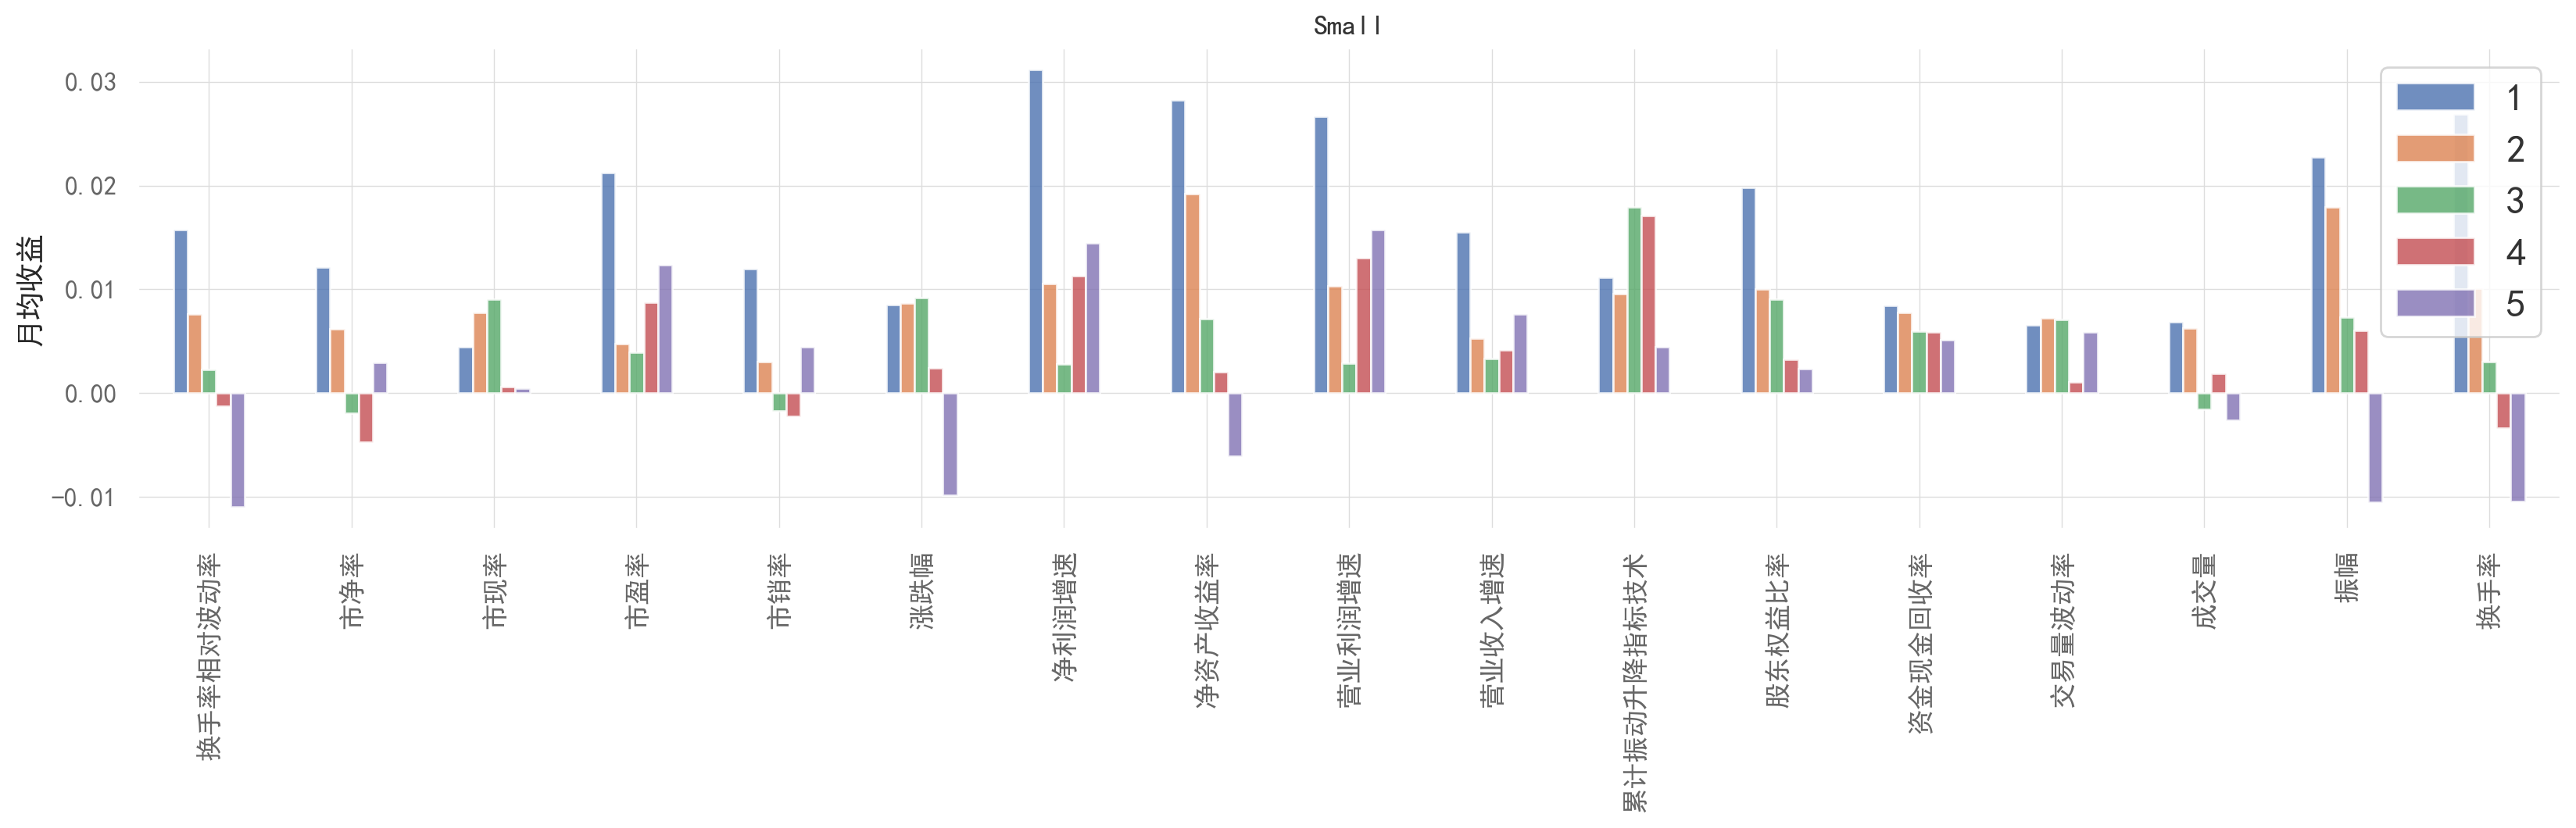

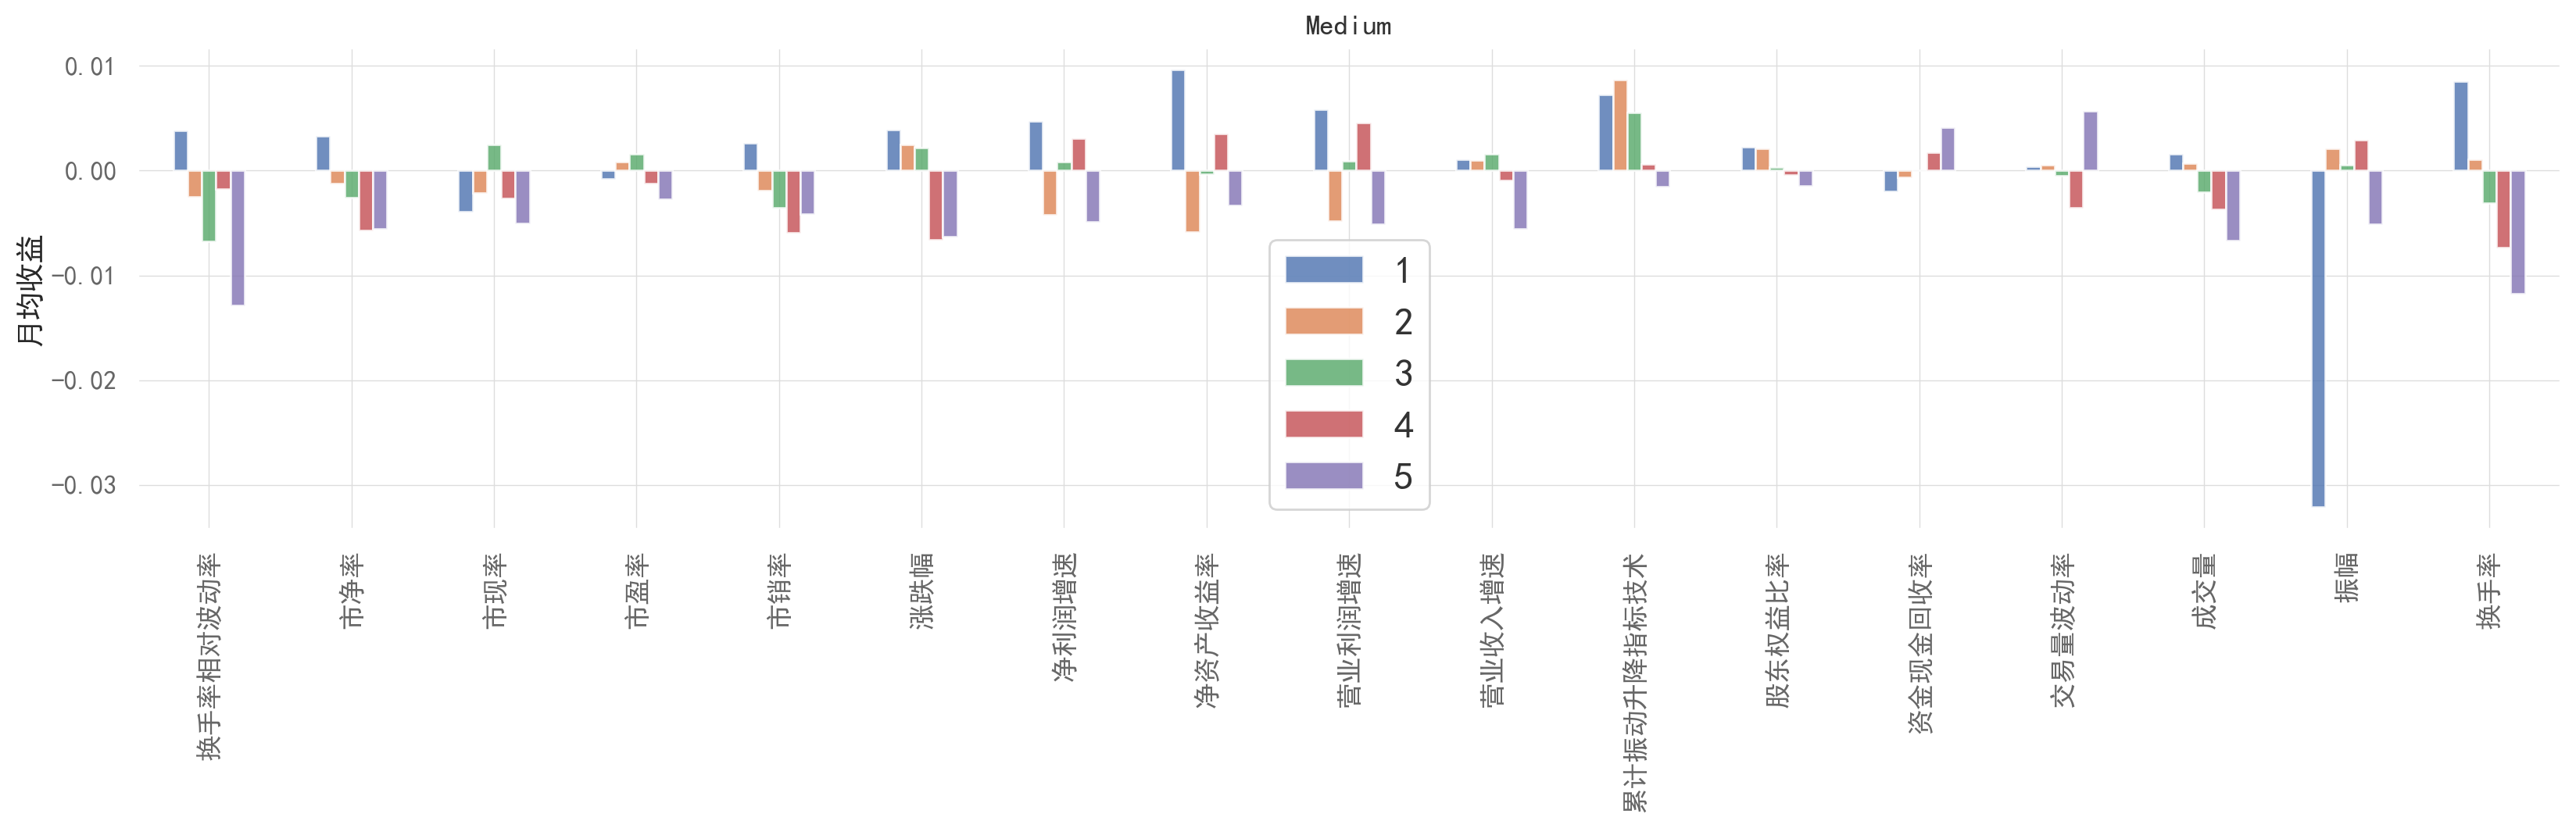

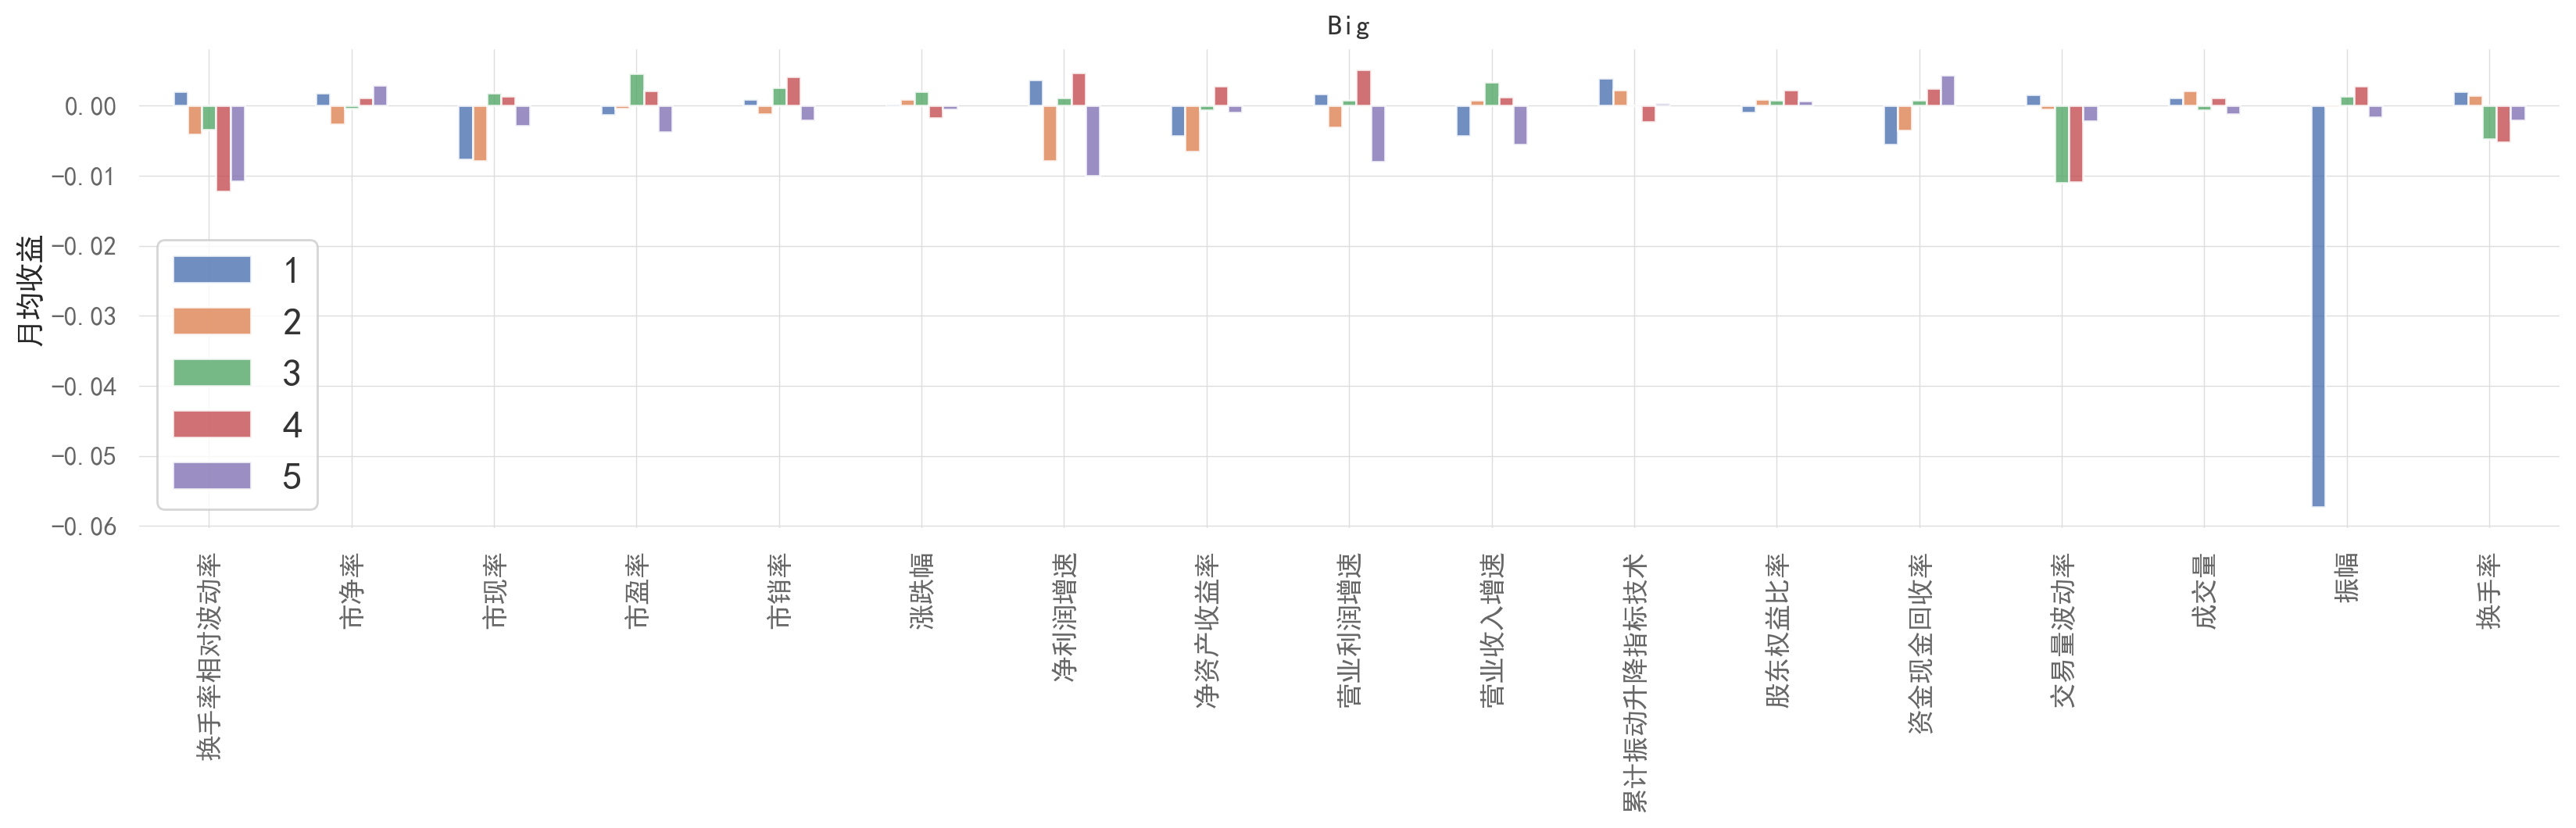

In [27]:
for flag in ["Small", "Medium", "Big"]:
    lst = []
    data_size = data[data["Flag"]==flag]
    for test_factor in factors_lst:
        if test_factor == market_value_col:
            continue
        tmp_cust_num = 5
        tmp_cust_num_lst = ["1", "2", "3", "4", "5"]
        tmp_data = data_size[[date_col, test_factor, target]]
        data_cut = pd.cut(tmp_data[test_factor], tmp_cust_num, labels=tmp_cust_num_lst)
        tmp_group = tmp_data.groupby(data_cut)[target].mean().to_frame(name=test_factor)
        lst.append(tmp_group)

    group = pd.concat(lst, axis=1).T
    _ = group.plot.bar(figsize=(20, 4), alpha=0.8, align='center');
    _ = plt.ylabel('月均收益')
    _ = plt.xlabel(None)
    _ = plt.title(flag)
    _ = plt.legend(loc = "best")
    # plt.savefig(os.path.join(fig_path, f'{dic.get(test_factor)}bar.png'), bbox_inches='tight')

In [28]:
group_lst = []
for flag in ["Small", "Medium", "Big"]:
    lst = []
    col_lst = []
    data_size = data[data["Flag"]==flag]
    for test_factor in factors_lst:
        if test_factor == market_value_col:
            continue
        col_lst.append(test_factor)
        tmp_cust_num = 5
        tmp_cust_num_lst = ["1", "2", "3", "4", "5"]
        tmp_data = data_size[[date_col, test_factor, target]]
        data_cut = pd.cut(tmp_data[test_factor], tmp_cust_num, labels=tmp_cust_num_lst)
        tmp_group1 = tmp_data.groupby(data_cut)[target].mean().to_frame(name=test_factor)
        tmp_group2 = tmp_data.groupby(data_cut)[target].std().to_frame(name=test_factor)
        tmp_group = pd.concat([tmp_group1, tmp_group2], axis=1)
        tmp_group.columns = ["收益率", "波动率"]
        tmp_group["夏普率"] = tmp_group1/tmp_group2
        if metrics.loc[test_factor, 'IC mean'] < 0:
            tmp_group = tmp_group.loc["1", :]
        else:
            tmp_group = tmp_group.loc["5", :]
        lst.append(tmp_group)
    group = pd.concat(lst, axis=1).T
    group.index = col_lst
    group.columns = pd.MultiIndex.from_tuples(zip([flag]*3, ["收益率", "波动率", "夏普率"]))
    group_lst.append(group)
layers = pd.concat(group_lst, axis=1)
layers

Small                        Medium                      \
                 收益率       波动率       夏普率       收益率       波动率       夏普率   
换手率相对波动率    0.015781  0.151082  0.104457  0.003854  0.132734  0.029039   
市净率         0.012154  0.154133  0.078851  0.003347  0.135263  0.024742   
市现率         0.004487  0.171949  0.026093 -0.003907  0.152124 -0.025685   
市盈率         0.021248  0.164524  0.129149 -0.000799  0.145790 -0.005484   
市销率         0.011962  0.154308  0.077519  0.002671  0.135584  0.019700   
涨跌幅         0.008558  0.172666  0.049564  0.003920  0.159611  0.024559   
净利润增速       0.031142  0.179792  0.173214  0.004736  0.157664  0.030037   
净资产收益率     -0.006028  0.180589 -0.033378 -0.003286  0.138625 -0.023701   
营业利润增速      0.015741  0.165291  0.095231 -0.005096  0.144209 -0.035338   
营业收入增速      0.007650  0.173114  0.044190 -0.005543  0.150324 -0.036877   
累计振动升降指标技术  0.011189  0.153053  0.073105  0.007251  0.133396  0.054359   
股东权益比率      0.019817  0.169594  0.116847  0.002290  0.143800  0.015926   
资金现金回收率     0.005128  0.159481  0.032157  0.004103  0.137804  0.029776   
交易量波动率      0.005914  0.172930  0.034201  0.005676  0.162924  0.034841   
成交量         0.006887  0.162143  0.042477  0.001566  0.143292  0.010926   
振幅          0.022716  0.268106  0.084729 -0.032128  0.196824 -0.163232   
换手率         0.026920  0.191236  0.140767  0.008554  0.144918  0.059024   

                 Big                      
                 收益率       波动率       夏普率  
换手率相对波动率    0.002102  0.121795  0.017260  
市净率         0.001789  0.115836  0.015443  
市现率        -0.007619  0.138632 -0.054955  
市盈率        -0.001320  0.149995 -0.008798  
市销率         0.000954  0.122014  0.007815  
涨跌幅         0.000174  0.135850  0.001283  
净利润增速       0.003720  0.146254  0.025434  
净资产收益率     -0.000990  0.128410 -0.007709  
营业利润增速     -0.008003  0.145981 -0.054825  
营业收入增速     -0.005562  0.151790 -0.036642  
累计振动升降指标技术  0.003923  0.127292  0.030822  
股东权益比率     -0.000962  0.123298 -0.007799  
资金现金回收率     0.004437  0.128005  0.034660  
交易量波动率     -0.002148  0.158257 -0.013573  
成交量         0.001163  0.130458  0.008915  
振幅         -0.057324  0.196751 -0.291353  
换手率         0.002062  0.113036  0.018243

## 因子共线性

In [29]:
def correlation(dataset, threshold):
    '''删除相关性高的特征'''
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (corr_matrix.iloc[i, j] >= threshold) and (corr_matrix.columns[j] not in col_corr):
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
                if colname in dataset.columns:
                    del dataset[colname]
                    print("删除特征：{}".format(colname))

    return dataset

<Figure size 3000x1400 with 0 Axes>

<Axes: >

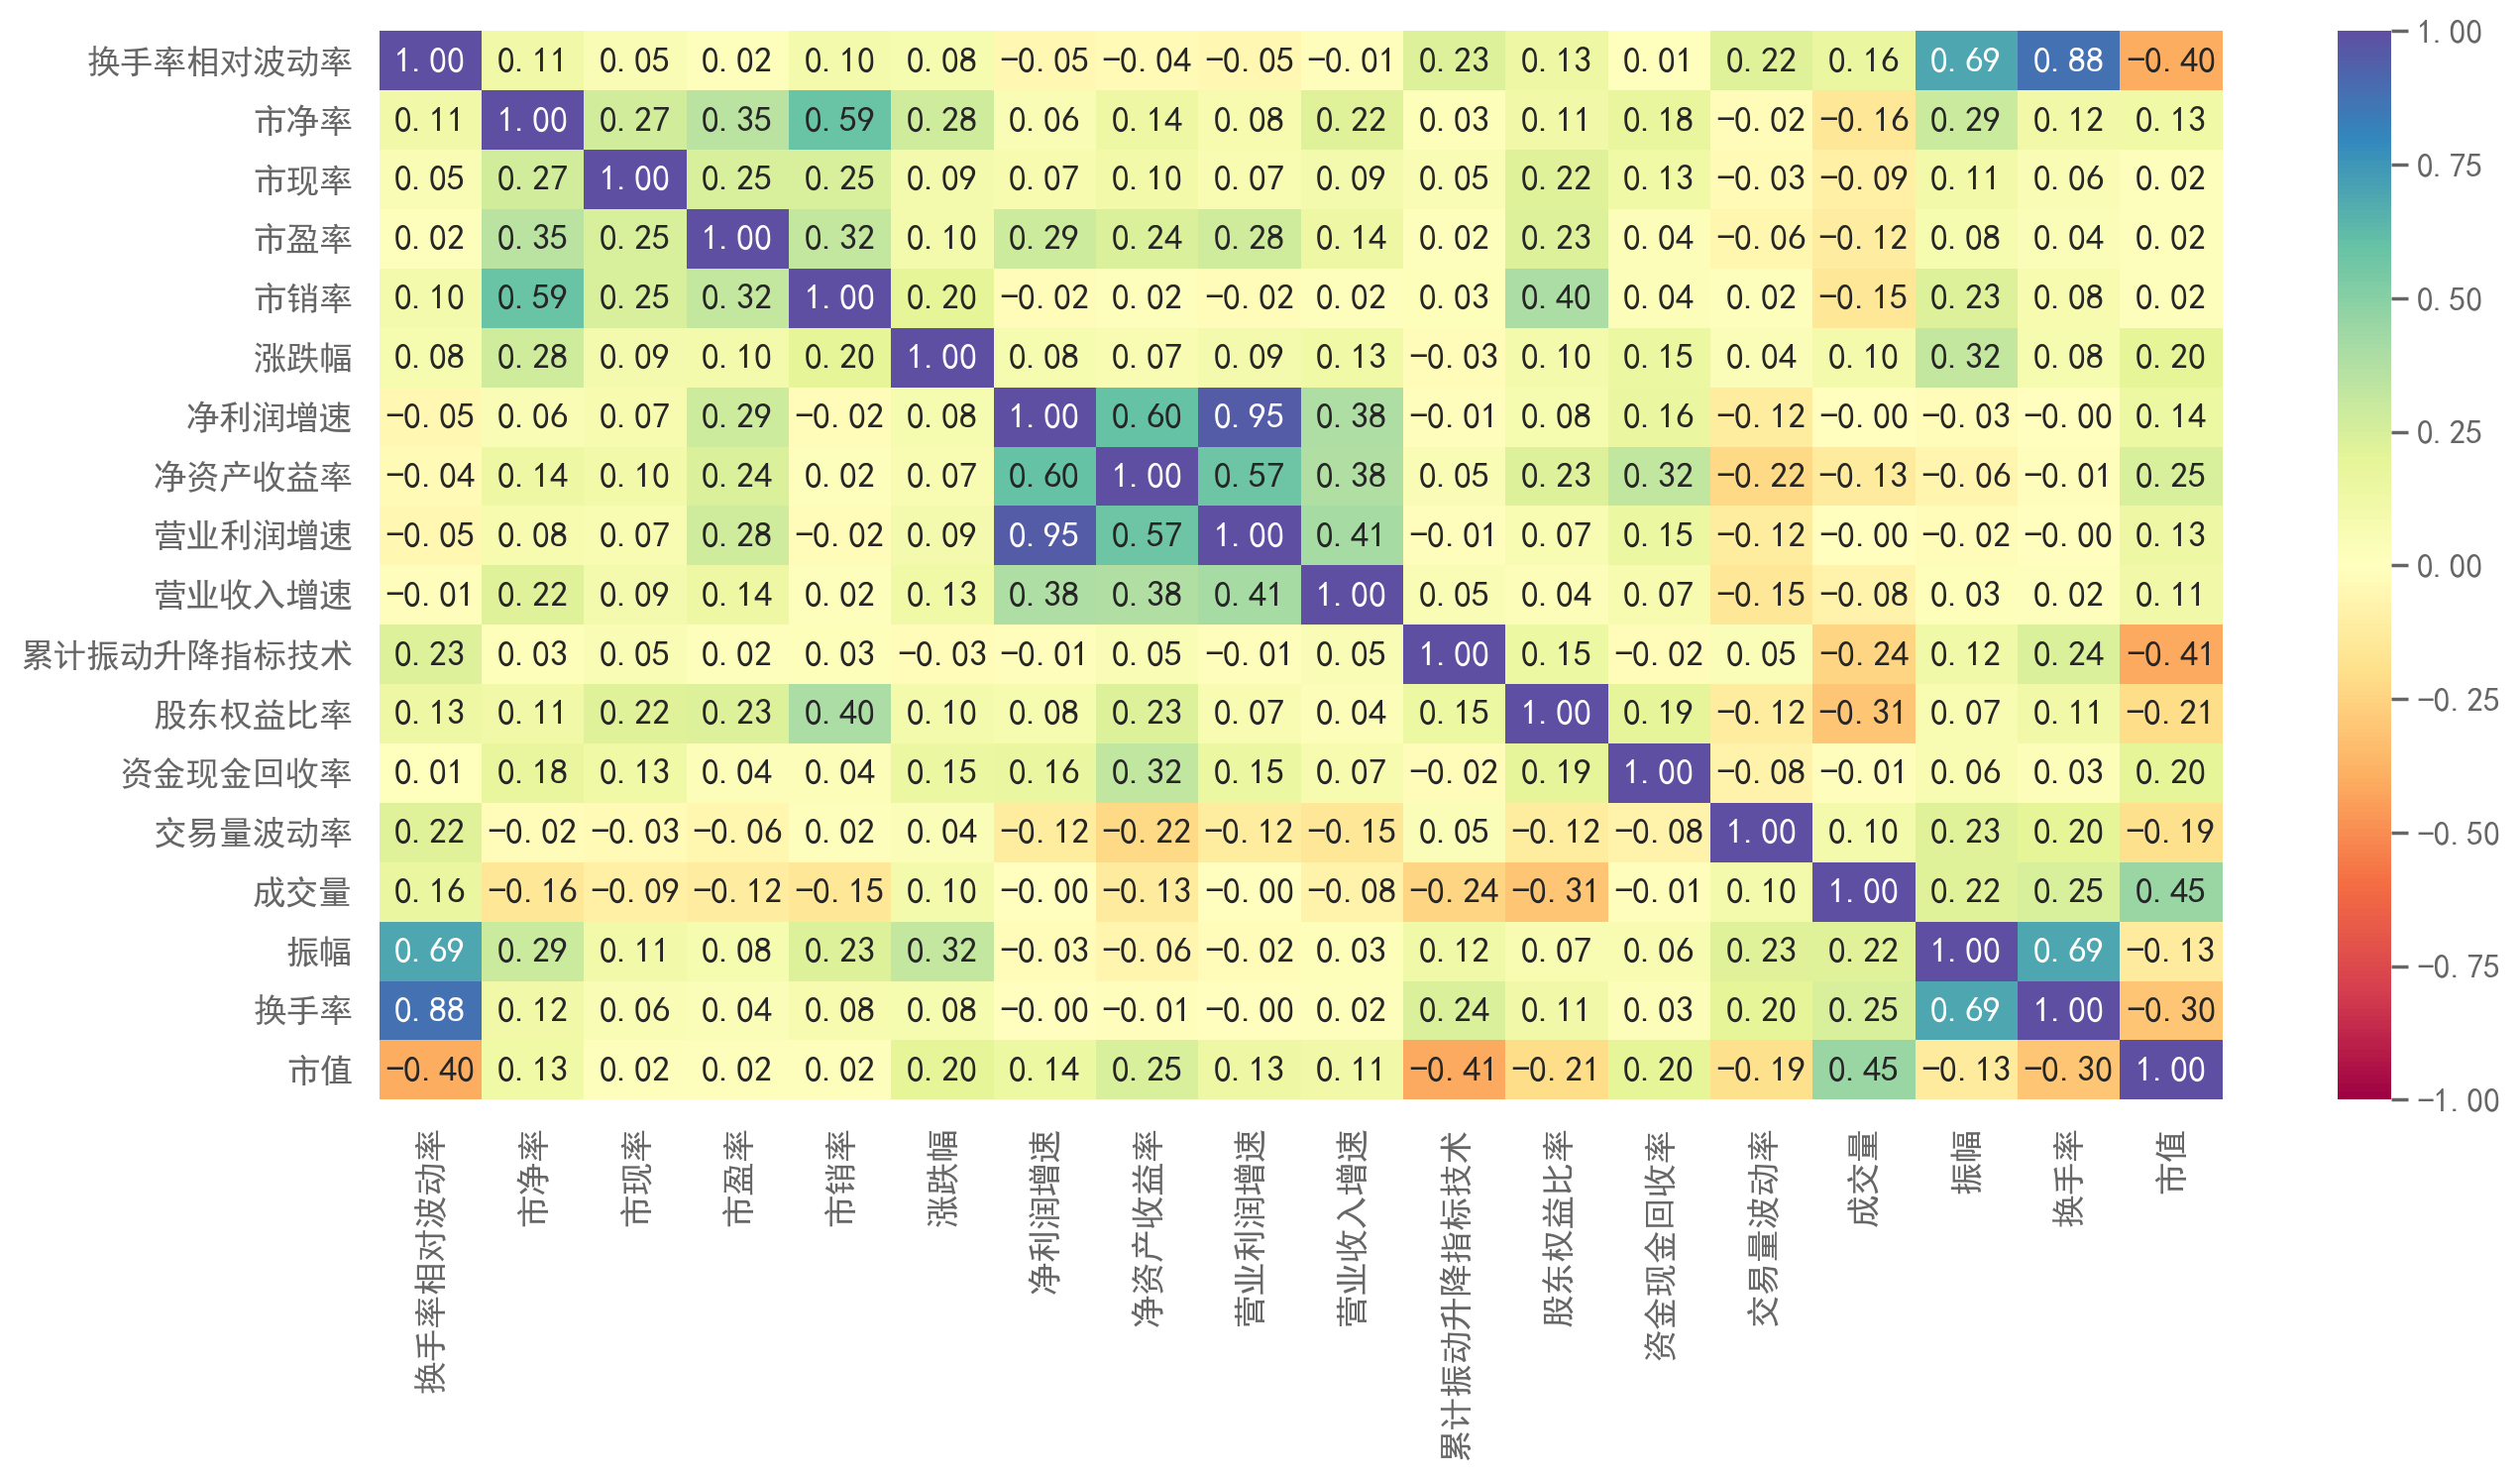

In [30]:
factors_corr = data[data[date_col]=='2021-04-30'][factors_lst].corr()
plt.figure(figsize=(15, 7))
sns.heatmap(factors_corr, annot=True, vmin=-1, vmax=1, 
            fmt=".2f", cmap="Spectral", annot_kws={"fontsize":13})
plt.savefig(generateFilePath("corr"), bbox_inches='tight')

# 因子打分法回测

In [31]:
import numpy as np
tradedate = data[date_col].unique()
count = 0
gap = 1
all_ret = []
all_t = []

while True:
    if count>len(tradedate)-12:
        break
    # 一年的数据量，按月滚动
    split_data = data[(data[date_col]<tradedate[11+count])&(data[date_col]>=tradedate[count])]
    icall = getICSeries(split_data, factors_lst, target)
    
    # 筛选有效因子
    sort_ic = pd.DataFrame(abs(icall.mean()))
    sort_ic = sort_ic.sort_values(by=0, ascending=False)
    sort_ic = sort_ic[sort_ic[0]>0.03]
    X = icall.copy()
    X = X[sort_ic.index]
    X = correlation(X, 0.7)
    
    # 最新一期数据
    now_factor = data[data[date_col] == tradedate[11+count]]
    all_code = pd.DataFrame()
    all_code["Code"] = now_factor[stock_col]
    for f in X.columns.values: 
        # 按照因子f，股票的分位数
        cut_num = 5
        if icall.mean()[f] > 0:
            all_code[f] = pd.cut(now_factor[f], cut_num, labels=np.arange(1, cut_num+1))
        else:
            all_code[f] = pd.cut(now_factor[f], cut_num, labels=np.arange(1, cut_num+1)[::-1])
            
    # 按照所有因子对股票的排名sum
    score = all_code.iloc[:, 1:].sum(axis=1)
    all_sc = now_factor[[stock_col, target]]
    all_sc["Score"] = score
    all_sc = all_sc.sort_values(by = "Score")

    # 购买排名前5%，10%，20%的股票
    Num = [int(i*len(all_sc)) for i in [0.05, 0.1, 0.2]]
    r = [sum(all_sc[target][-n:])/n for n in Num]
    
    # 记录收益率
    all_ret.append(r)
    # 记录交易日
    all_t.append(tradedate[11+count])
    count += gap

C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\2774934527.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  icall= factors_data[[date_col]+factors_lst+[target]].groupby(date_col).apply(lambda x: x.corr(method='spearman')[target]).reset_index()
C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\1600410542.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_sc["Score"] = score
C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\2774934527.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. 

删除特征：换手率相对波动率
删除特征：振幅
删除特征：股东权益比率
删除特征：市净率
删除特征：换手率相对波动率
删除特征：换手率相对波动率
删除特征：换手率相对波动率
删除特征：换手率相对波动率


C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\1600410542.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_sc["Score"] = score
C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\2774934527.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  icall= factors_data[[date_col]+factors_lst+[target]].groupby(date_col).apply(lambda x: x.corr(method='spearman')[target]).reset_index()
C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\1600410542.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

删除特征：换手率相对波动率
删除特征：换手率相对波动率
删除特征：换手率相对波动率
删除特征：换手率相对波动率


C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\1600410542.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_sc["Score"] = score
C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\2774934527.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  icall= factors_data[[date_col]+factors_lst+[target]].groupby(date_col).apply(lambda x: x.corr(method='spearman')[target]).reset_index()
C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\1600410542.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

...

C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\1600410542.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_sc["Score"] = score
C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\2774934527.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  icall= factors_data[[date_col]+factors_lst+[target]].groupby(date_col).apply(lambda x: x.corr(method='spearman')[target]).reset_index()
C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\1600410542.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

删除特征：换手率相对波动率
删除特征：振幅
删除特征：资金现金回收率
删除特征：换手率相对波动率
删除特征：振幅
删除特征：市销率
删除特征：换手率相对波动率
删除特征：振幅
删除特征：净资产收益率
删除特征：市值
删除特征：市销率
删除特征：营业利润增速
删除特征：净利润增速


C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\1600410542.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_sc["Score"] = score
C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\2774934527.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  icall= factors_data[[date_col]+factors_lst+[target]].groupby(date_col).apply(lambda x: x.corr(method='spearman')[target]).reset_index()
C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\1600410542.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

删除特征：换手率相对波动率
删除特征：振幅
删除特征：市销率
删除特征：市净率
删除特征：净资产收益率
删除特征：换手率相对波动率
删除特征：振幅
删除特征：市净率
删除特征：市销率
删除特征：市盈率
删除特征：市现率
删除特征：股东权益比率
删除特征：换手率相对波动率
删除特征：市净率
删除特征：市销率
删除特征：振幅
删除特征：市盈率
删除特征：股东权益比率
删除特征：市现率
删除特征：换手率相对波动率
删除特征：市销率
删除特征：振幅
删除特征：股东权益比率
删除特征：市盈率
删除特征：市现率
删除特征：营业收入增速


C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\1600410542.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_sc["Score"] = score
C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\2774934527.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  icall= factors_data[[date_col]+factors_lst+[target]].groupby(date_col).apply(lambda x: x.corr(method='spearman')[target]).reset_index()
C:\Users\hyliu\AppData\Local\Temp\ipykernel_21684\1600410542.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_index

## CSI300基线

In [32]:
# CSI300收益率
bench = pd.read_csv(f"csi300_bench.csv", parse_dates=[date_col])
bench.head()

,datetime,开盘点位,最高点位,最低点位,Close,涨跌,涨跌幅(%),开始日累计涨跌,开始日累计涨跌幅,成交量(万股),成交额(万),1M,3M,5M,10M
0,2011-01-31,3035.42,3076.55,3032.45,3076.51,-51.75,-1.65,-51.75,-1.65,671059.14,8307030.94,0.052998,0.037773,-0.010538,-0.180396
1,2011-02-28,3200.68,3241.60,3178.83,3239.56,163.05,5.30,111.30,3.56,766306.63,10924997.08,-0.005022,-0.073467,-0.082567,-0.275908
2,2011-03-31,3257.16,3264.96,3210.17,3223.29,-16.27,-0.50,95.03,3.04,645038.80,8656537.27,-0.009484,-0.055595,-0.116809,-0.235483
3,2011-04-29,3161.16,3193.60,3147.14,3192.72,-30.57,-0.95,64.46,2.06,536830.65,6345581.43,-0.059874,-0.069107,-0.191489,-0.174954
4,2011-05-31,2958.61,3001.73,2946.15,3001.56,-191.17,-5.99,-126.70,-4.05,396893.99,5055338.62,0.014169,-0.051567,-0.102030,-0.182125


## 回测走势

In [33]:
# 收益率细节
return_detail = pd.DataFrame(all_ret,  columns=["0.05", "0.1", "0.2"])
return_detail[date_col] = all_t
return_detail = return_detail.merge(bench[[date_col]+[target]], on=date_col)

# 根据标签调整实际交易日期
return_detail[date_col] = pd.to_datetime(return_detail[date_col].apply(_getPreDate, gap=int(target[:-1])))
return_detail = return_detail.set_index(date_col)
return_detail.to_csv("return_detail.csv")

<Figure size 2400x1200 with 0 Axes>

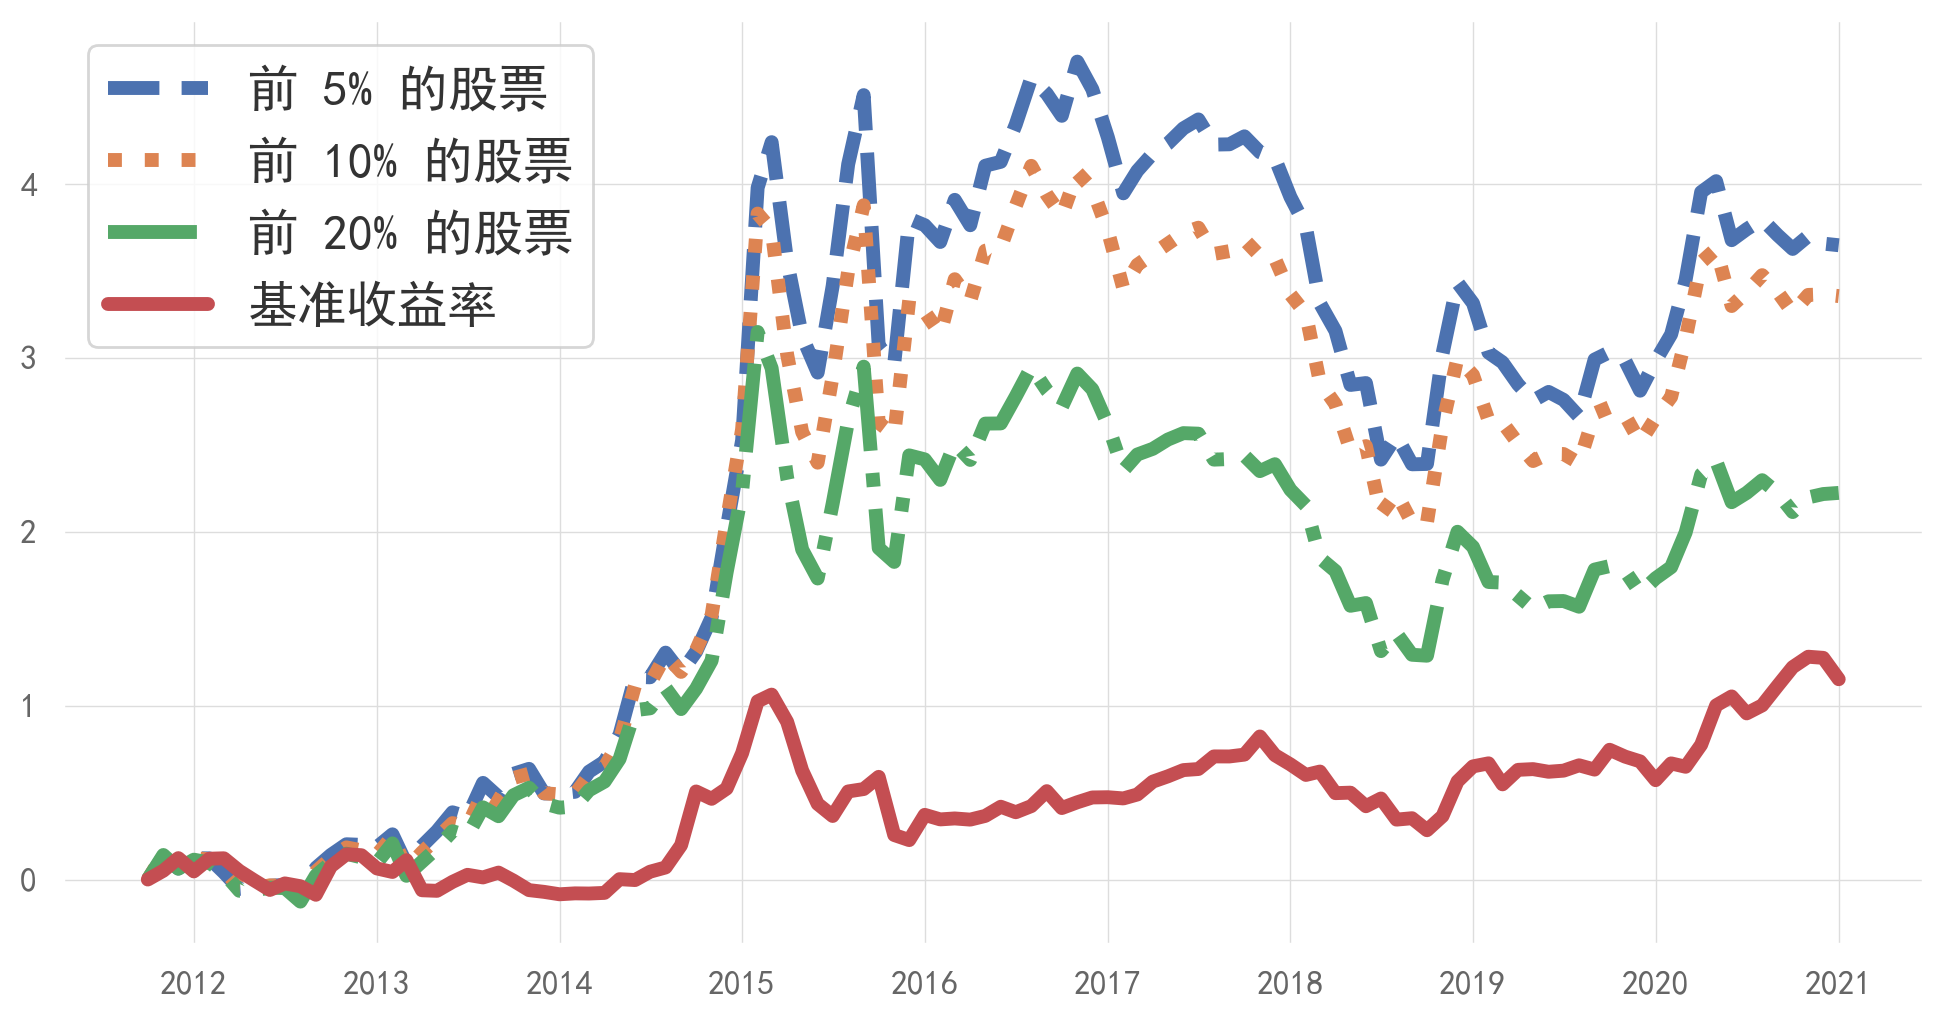

In [34]:
# 累计收益率
accReturn = pd.DataFrame(index = return_detail.index)
accReturn["前 5% 的股票"] = (return_detail["0.05"].values + 1).cumprod()-1
accReturn["前 10% 的股票"] = (return_detail["0.1"].values + 1).cumprod()-1
accReturn["前 20% 的股票"] = (return_detail["0.2"].values + 1).cumprod()-1
accReturn["基准收益率"] = (return_detail[target].values + 1).cumprod()-1
# 初始化收益
mindate = getPreDate(accReturn.index)
accReturn.loc[f"{mindate}", :] = 0
accReturn = accReturn.sort_index()

plt.figure(figsize=(12, 6))
plt.plot(accReturn["前 5% 的股票"], linestyle='dashed', label="前 5% 的股票")
plt.plot(accReturn["前 10% 的股票"], linestyle='dotted', label="前 10% 的股票")
plt.plot(accReturn["前 20% 的股票"], linestyle='dashdot', label="前 20% 的股票")
plt.plot(accReturn["基准收益率"], label="基准收益率")
plt.legend()
plt.savefig(generateFilePath("backtest"), dpi=500, bbox_inches = 'tight')

<Figure size 2400x1200 with 0 Axes>

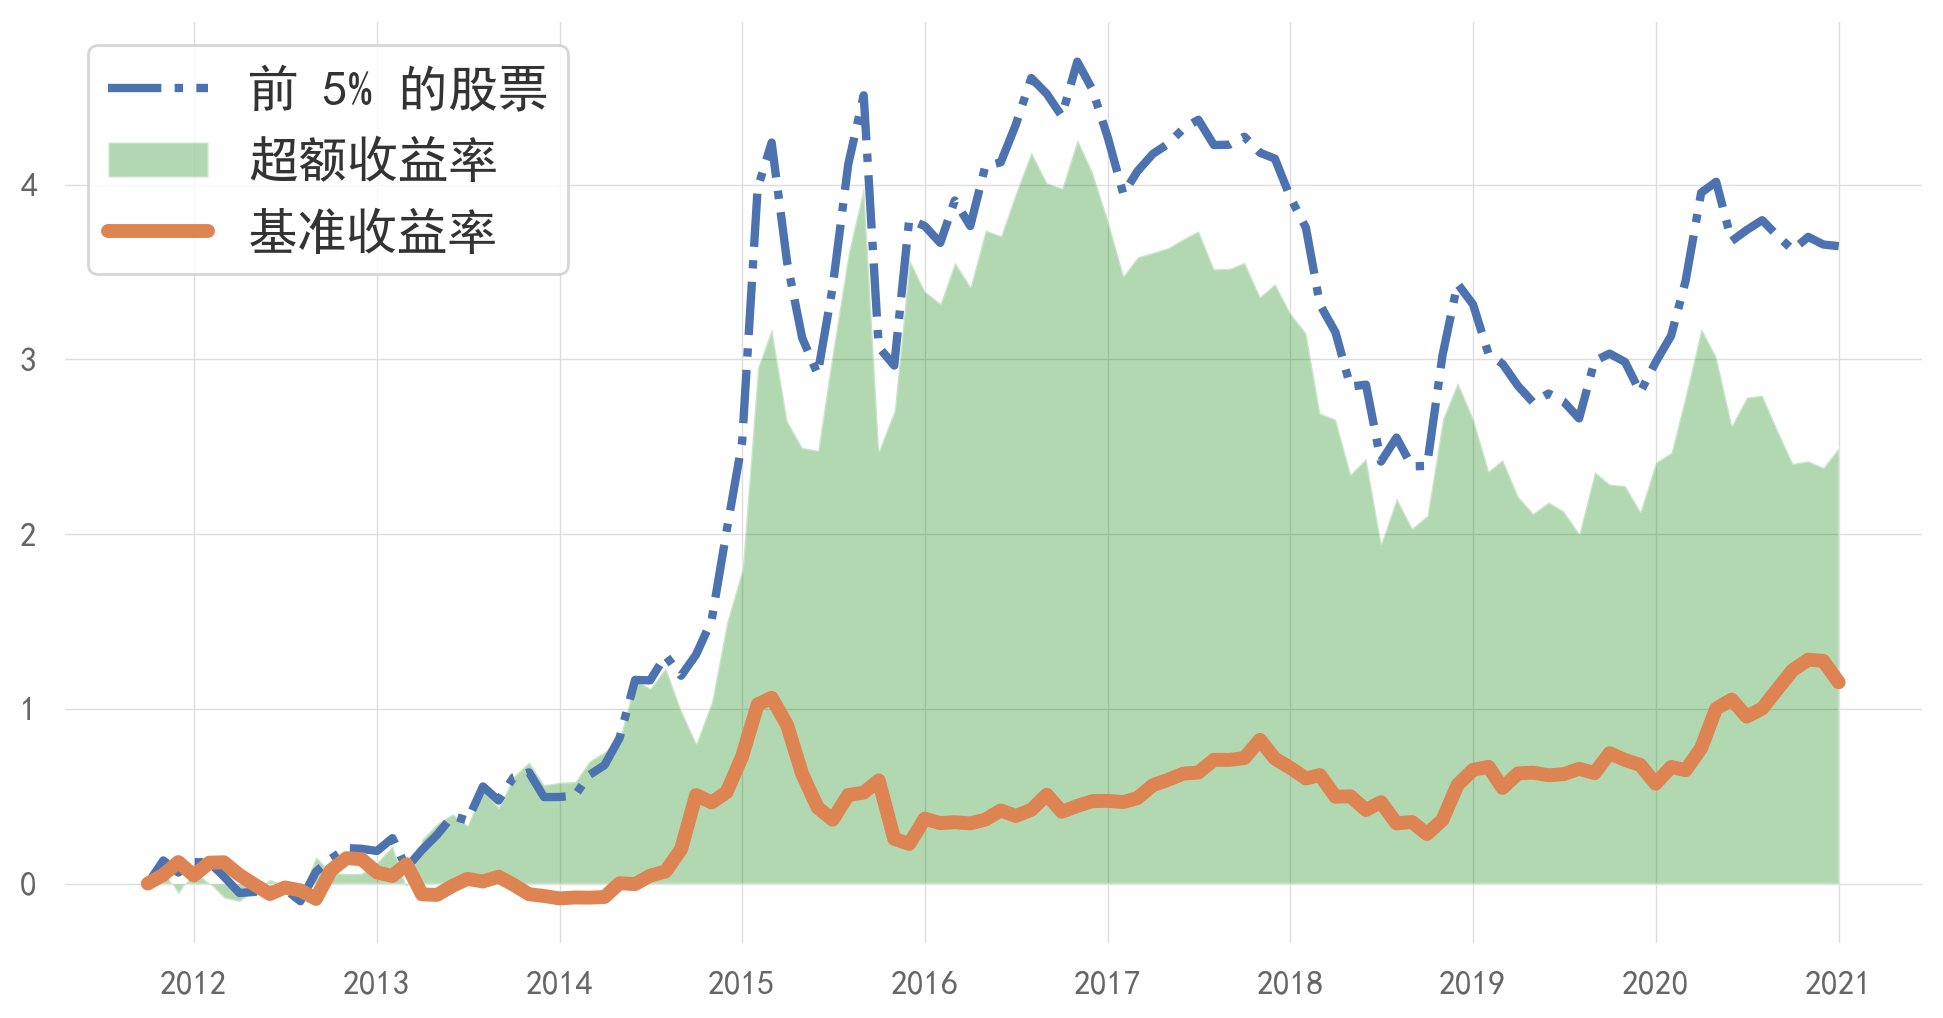

In [35]:
accReturn["超额收益率"] = accReturn["前 5% 的股票"] - accReturn["基准收益率"]
plt.figure(figsize=(12, 6))
plt.plot(accReturn["前 5% 的股票"], linestyle='-.',lw=3, label="前 5% 的股票")
plt.fill_between(accReturn.index, 0, accReturn["超额收益率"], 
                 facecolor='green', alpha=0.3, label="超额收益率")
plt.plot(accReturn["基准收益率"], label="基准收益率")
plt.legend()
plt.savefig(generateFilePath("backtest2"), dpi=500, bbox_inches='tight')

## 回测指标

In [36]:
import pandas as pd
import quantstats as qs
date_col = "datetime"
return_detail = pd.read_csv("./data/return_detail.csv", index_col=[date_col], parse_dates=True)

In [37]:
return_detail.head()

,0.05,0.1,0.2,1M
datetime,,,,
2011-11-01,0.132307,0.144394,0.140966,0.050526
2011-12-01,-0.061153,-0.063257,-0.069146,0.068938
2012-01-01,0.055895,0.046596,0.048951,-0.068045
2012-02-01,-0.000875,-0.004106,-0.015025,0.069763
2012-03-01,-0.072028,-0.056222,-0.054523,0.002239


In [38]:
qs.reports.metrics(return_detail[['0.05']], prepare_returns=False, 
                   display=False, mode="full") 

,Strategy
Start Period,2011-11-01
End Period,2021-01-01
Risk-Free Rate,0
Time in Market,1.0
Cumulative Return,3.65
...,...
Avg. Down Month,-0.05
Win Days,0.55
Win Month,0.55
Win Quarter,0.58


In [39]:
lst = []
for col in return_detail.columns:
    tmp_back_test = qs.reports.metrics(return_detail[[col]], prepare_returns=False, display=False, mode="full") 
    lst.append(tmp_back_test.loc[bt_indicators, :])
back_test = pd.concat(lst, axis=1)
back_test.columns = return_detail.columns
back_test.loc[bt_indicators, :].to_csv("./data/monthly_back_test.csv")

In [40]:
back_test

,0.05,0.1,0.2,1M
Cumulative Return,3.65,3.36,2.22,1.15
Volatility (ann.),1.34,1.32,1.3,1.06
Sharpe,3.25,3.18,2.69,2.16
Max Drawdown,-0.41,-0.4,-0.45,-0.41
Sortino,6.31,5.96,4.75,3.54
Omega,1.83,1.78,1.61,1.47


In [41]:
qs.reports.html(return_detail['0.05'], benchmark=return_detail[target], 
                title='Score', output='./filename1.html', download_filename='./filename1.html')

In [42]:
# [f for f in dir(qs.stats) if f[0] != '_']
# [f for f in dir(qs.plots) if f[0] != '_']
# [f for f in dir(qs.reports) if f[0] != '_']
# qs.reports.metrics() - 展现基础/所有指标
# qs.reports.plots() - 展现基础/所有绘图
# qs.reports.basic() - 展现基础指标和绘图
# qs.reports.full() - 展现所有指标和绘图
# qs.reports.html() - 生成html完整报告

# 组合优化

In [52]:
from sklearn.linear_model import LinearRegression

In [44]:
# 当日股票收益，筛选300只股票
returns = data[[date_col, stock_col, target]].groupby(stock_col).shift(1)
returns[stock_col] = data[stock_col]
returns = returns.dropna()
returns = returns.pivot(index=date_col, columns=stock_col, values=target) 
returns = returns.dropna(axis=1)
returns = returns.sample(100, axis=1, random_state=12)

# 回测日期
t_oos = returns.index.tolist()[-24:]
Tt = len(t_oos)
Tt
nb_port = 4
portf_weights = np.zeros(Tt*nb_port*returns.shape[1]).reshape(Tt, nb_port, 
                                                              returns.shape[1])
portf_returns = np.zeros(Tt*nb_port).reshape(Tt, nb_port)

24

In [45]:
returns.shape

(123, 100)

In [46]:
def weights_sparsehedge(returns, alpha, l1_ratio):
    w = np.zeros(returns.shape[1])
    for i, col in enumerate(returns.columns): 
        y = returns[[col]].values
        X = returns.drop([col], axis=1).values 
        # model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
        #                    fit_intercept = True, normalize = True,
        #                    tol=1e-7, max_iter = 1000000)
        model = Lasso(alpha=alpha,
                   fit_intercept = True,
                   tol=1e-7, max_iter = 1000000)
        model.fit(X, y)
        
        # 误差项
        err = y.ravel() - model.predict(X).T
        w[i] = (1- np.sum(model.coef_))/ np.square(np.std(err, ddof=1))
    return w/np.sum(w)  # 归一化

def weights_olshedge(returns):
    w = np.zeros(returns.shape[1])
    for i, col in enumerate(returns.columns):
        y = returns[[col]].values
        X = returns.drop([col], axis=1).values
        model = LinearRegression(fit_intercept = True)
        model.fit(X, y)
        
        # 误差项
        err = y.ravel() - model.predict(X).T
        w[i] = (1- np.sum(model.coef_))/ np.square(np.std(err, ddof=1))
    return w/np.sum(w)  # 归一化

def weights_multi(returns, j, alpha, l1_ratio):
    N = returns.shape[1]
    if(j == 1): # 等权
        return np.ones(N) / N
    if(j == 2):  # 最小方差
        # Covariance matrix + regularizing term
        # grouped by every stock
        sigma = np.cov(np.array(returns.values), rowvar=False)
        sigma += 0.01*np.eye(N)  
        # Inverse & multiply
        w = (np.linalg.inv(sigma)@np.ones(N).reshape(N, 1)).ravel() 
        return w/sum(w) 
    if(j == 3):  # lasso
        return weights_sparsehedge(returns, alpha, l1_ratio)
    if(j == 4): # ols
        return weights_olshedge(returns)

In [47]:
for t in tqdm(range(len(t_oos))):
    # 历史收益
    temp_data = returns[returns.index < t_oos[t]]
    # t时刻收益
    realised_returns = returns[returns.index == t_oos[t]]
    for j in range(1, nb_port+1):
        # 权重
        portf_weights[t,j-1,:] = weights_multi(temp_data, j, 0.1, 0.1)
        # 实际收益
        portf_returns[t,j-1] = np.sum(portf_weights[t,j-1,:] * realised_returns.values)

  0%|          | 0/24 [00:00<?, ?it/s]

In [48]:
lst = []
portf_returns_detail = pd.DataFrame(portf_returns, index=t_oos, columns=["EW", "MV", "Sparse", 'OLSW'])
for col in portf_returns_detail.columns:
    tmp_back_test = qs.reports.metrics(portf_returns_detail[[col]], prepare_returns=False, display=False, mode="full") 
    lst.append(tmp_back_test.loc[bt_indicators, :])
opt_back_test = pd.concat(lst, axis=1)
opt_back_test.columns = portf_returns_detail.columns

In [49]:
opt_back_test

,EW,MV,Sparse,OLSW
Cumulative Return,0.23,0.82,0.29,-1.01
Volatility (ann.),0.7,0.71,0.69,5.15
Sharpe,3.47,9.36,4.21,2.73
Max Drawdown,-0.11,-0.05,-0.09,-1.0
Sortino,7.23,30.45,9.32,3.92
Omega,1.92,5.69,2.22,1.66


In [50]:
opt_back_test.to_csv("./data/opt_back_test.csv")

In [51]:
# tmp_df = pd.DataFrame({"return":np.mean(portf_returns,axis=0), 
#                    "volatility":np.std(portf_returns, axis=0, ddof=1), 
#                    "sharpe":np.mean(portf_returns,axis=0)/np.std(portf_returns, axis=0, ddof=1)},
#                   index = ["EW", "MV", "Sparse", 'OLSW']
#                  ).T 
# tmp_df.applymap(lambda x: "{:.4f}".format(x))